In [ ]:
import os

# Print the folder you are currently in and all files inside it
print("Current Working Directory:", os.getcwd())
print("\nFiles in this folder:")
for file in os.listdir():
    if file.endswith('.csv'):
        print(f" - {file}")

Current Working Directory: c:\Users\pc\Desktop\zindi,,ML,,AI,,Datascience\mobile money transactions to spot early signs of financial hardship

Files in this folder:
 - baseline_submission.csv
 - data_dictionary.csv
 - day12_lightgbm_sub.csv
 - ensemble_submission.csv
 - feature_engineered_sub_v1.csv
 - feature_engineered_sub_v2.csv
 - final_best_single_sub.csv
 - grouped_aggs_ensemble_sub.csv
 - histgb_lightgbm_blend_sub.csv
 - multi_model_ensemble_sub.csv
 - optuna_tuned_sub.csv
 - pruned_features_sub.csv
 - SampleSubmission.csv
 - Test.csv
 - Train.csv
 - tuned_calibrated_sub.csv


In [ ]:
import pandas as pd
import numpy as np

# Step 1: Loading the datasets into Pandas DataFrames
print("Loading data...")
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

# Step 2: Check dataset dimensions (rows, columns)
print("\n--- 1. DATASET SHAPES ---")
print(f"Train Shape: {train.shape}")
print(f"Test Shape:  {test.shape}")
print(f"Sample Sub Shape: {sample_sub.shape}")

# Step 3: Inspection of the Target Variable distribution
print("\n--- 2. TARGET DISTRIBUTION ---")
target_col = 'liquidity_stress_next_30d'
counts = train[target_col].value_counts()
percentages = train[target_col].value_counts(normalize=True) * 100

target_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
print(target_df)

# Step 4: Verification of missing values
print("\n--- 3. MISSING VALUE CHECK ---")
print(f"Total missing values in Train: {train.isnull().sum().sum()}")
print(f"Total missing values in Test:  {test.isnull().sum().sum()}")

# Step 5: Quick preview of first 5 rows and 5 columns
print("\n--- 4. TRAIN HEAD PREVIEW ---")
print(train.iloc[:5, :5])

Loading data...

--- 1. DATASET SHAPES ---
Train Shape: (40000, 184)
Test Shape:  (30000, 183)
Sample Sub Shape: (30000, 2)

--- 2. TARGET DISTRIBUTION ---
                           Count  Percentage (%)
liquidity_stress_next_30d                       
0                          34000            85.0
1                           6000            15.0

--- 3. MISSING VALUE CHECK ---
Total missing values in Train: 0
Total missing values in Test:  0

--- 4. TRAIN HEAD PREVIEW ---
       arpu  age gender              region smartphone
0   2653.88   47      F        Central Zone        Yes
1   2653.88   47      F        Central Zone        Yes
2   2653.88   47      F        Central Zone        Yes
3   2653.88   47      F        Central Zone        Yes
4  20535.82   63      F  Northern Highlands         No


In [ ]:
# Step 6: Categorical Features vs Target Analysis
cat_cols = ['gender', 'smartphone', 'segment', 'earning_pattern', 'region']

print("--- CATEGORICAL FEATURES vs LIQUIDITY STRESS RATE ---")
for col in cat_cols:
    print(f"\n=================== {col.upper()} ===================")
    
    # Group by category and calculate counts and stress percentages
    summary = train.groupby(col)['liquidity_stress_next_30d'].agg(
        Total_Customers='count',
        Stressed_Customers='sum',
        Stress_Rate_Pct=lambda x: round(x.mean() * 100, 2)
    )
    print(summary)

--- CATEGORICAL FEATURES vs LIQUIDITY STRESS RATE ---

=================== GENDER ===================
        Total_Customers  Stressed_Customers  Stress_Rate_Pct
gender                                                      
F                 23908                3535            14.79
M                 16092                2465            15.32

=================== SMARTPHONE ===================
            Total_Customers  Stressed_Customers  Stress_Rate_Pct
smartphone                                                      
No                    18044                2705            14.99
Yes                   21956                3295            15.01

=================== SEGMENT ===================
         Total_Customers  Stressed_Customers  Stress_Rate_Pct
segment                                                      
HVC                 3736                 711            19.03
LVC                15732                2710            17.23
MVC                20532                2579 

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, log_loss

# 1. Load Data
print("Loading datasets...")
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

# 2. Separate Features and Target
target_col = 'liquidity_stress_next_30d'
X = train.drop(columns=['ID', target_col])
y = train[target_col]
X_test = test.drop(columns=['ID'])

# 3. Handle Categorical Columns safely using OrdinalEncoder
cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

print("Categorical features encoded successfully!")

# 4. Setup 5-Fold Stratified Cross-Validation
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

print(f"\nStarting {N_SPLITS}-Fold Cross-Validation Training...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # Initialize Gradient Boosting model
    model = HistGradientBoostingClassifier(
        categorical_features=cat_cols,
        max_iter=300,
        learning_rate=0.03,
        random_state=42
    )
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict Out-Of-Fold probabilities
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    
    # Accumulate test predictions
    test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS
    
    # Fold scores
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    fold_loss = log_loss(y_val, oof_preds[val_idx])
    print(f"Fold {fold+1} | ROC-AUC: {fold_auc:.4f} | Log Loss: {fold_loss:.4f}")

# 5. Overall Out-of-Fold Score
overall_auc = roc_auc_score(y, oof_preds)
overall_loss = log_loss(y, oof_preds)

print(f"\n==========================================")
print(f"--- OVERALL BASELINE MODEL PERFORMANCE ---")
print(f"ROC-AUC Score:  {overall_auc:.4f}")
print(f"Log Loss Score: {overall_loss:.4f}")
print(f"==========================================")

# 6. Save baseline submission file
sample_sub['Target'] = test_preds
sample_sub.to_csv('baseline_submission.csv', index=False)
print("\nBaseline submission saved as 'baseline_submission.csv'!")

Loading datasets...
Categorical features encoded successfully!

Starting 5-Fold Cross-Validation Training...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, log_loss

# 1. Load Datasets
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

# 2. Feature Engineering Function: Trend & Momentum Features
def add_trend_features(df):
    df_feat = df.copy()
    
    # Balance trends (+1 added to avoid division by zero)
    df_feat['bal_ratio_m1_m6'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m6_daily_avg_bal'] + 1)
    df_feat['bal_diff_m1_m6'] = df_feat['m1_daily_avg_bal'] - df_feat['m6_daily_avg_bal']
    df_feat['bal_ratio_m1_m3'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m3_daily_avg_bal'] + 1)
    
    # Inflow Total (Received + Deposit + Bank Transfer)
    m1_inflow = df_feat['m1_received_total_value'] + df_feat['m1_deposit_total_value'] + df_feat['m1_transfer_from_bank_total_value']
    m6_inflow = df_feat['m6_received_total_value'] + df_feat['m6_deposit_total_value'] + df_feat['m6_transfer_from_bank_total_value']
    df_feat['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)
    
    # Outflow Total (Withdraw + MM Send + Paybill + Merchantpay)
    m1_outflow = df_feat['m1_withdraw_total_value'] + df_feat['m1_mm_send_total_value'] + df_feat['m1_paybill_total_value'] + df_feat['m1_merchantpay_total_value']
    m6_outflow = df_feat['m6_withdraw_total_value'] + df_feat['m6_mm_send_total_value'] + df_feat['m6_paybill_total_value'] + df_feat['m6_merchantpay_total_value']
    df_feat['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    return df_feat

# Apply feature engineering to train and test
train_feat = add_trend_features(train)
test_feat = add_trend_features(test)

print(f"Engineered {len(train_feat.columns) - len(train.columns)} new trend features!")

# 3. Prepare Data for Model
target_col = 'liquidity_stress_next_30d'
X = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test = test_feat.drop(columns=['ID'])

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

# 4. 5-Fold Stratified CV Evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_feat))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    model = HistGradientBoostingClassifier(
        categorical_features=cat_cols,
        max_iter=300,
        learning_rate=0.03,
        random_state=42
    )
    model.fit(X_tr, y_tr)
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]

# 5. Evaluate Scores
new_auc = roc_auc_score(y, oof_preds)
new_loss = log_loss(y, oof_preds)

print("\n==========================================")
print("--- MODEL EVALUATION: WITH TREND FEATURES ---")
print(f"ROC-AUC Score:  {new_auc:.4f}  (Baseline was 0.8764)")
print(f"Log Loss Score: {new_loss:.4f}  (Baseline was 0.2897)")
print("==========================================")

Engineered 5 new trend features!

--- MODEL EVALUATION: WITH TREND FEATURES ---
ROC-AUC Score:  0.8770  (Baseline was 0.8764)
Log Loss Score: 0.2868  (Baseline was 0.2897)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, log_loss

# 1. Load Data
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

# 2. Comprehensive Feature Engineering Function
def build_feature_pipeline(df):
    df_feat = df.copy()
    
    # --- PART 1: TREND & MOMENTUM FEATURES ---
    df_feat['bal_ratio_m1_m6'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m6_daily_avg_bal'] + 1)
    df_feat['bal_diff_m1_m6'] = df_feat['m1_daily_avg_bal'] - df_feat['m6_daily_avg_bal']
    df_feat['bal_ratio_m1_m3'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m3_daily_avg_bal'] + 1)
    
    m1_inflow = df_feat['m1_received_total_value'] + df_feat['m1_deposit_total_value'] + df_feat['m1_transfer_from_bank_total_value']
    m6_inflow = df_feat['m6_received_total_value'] + df_feat['m6_deposit_total_value'] + df_feat['m6_transfer_from_bank_total_value']
    df_feat['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)
    
    m1_outflow = df_feat['m1_withdraw_total_value'] + df_feat['m1_mm_send_total_value'] + df_feat['m1_paybill_total_value'] + df_feat['m1_merchantpay_total_value']
    m6_outflow = df_feat['m6_withdraw_total_value'] + df_feat['m6_mm_send_total_value'] + df_feat['m6_paybill_total_value'] + df_feat['m6_merchantpay_total_value']
    df_feat['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    # --- PART 2: 6-MONTH AGGREGATIONS & VOLATILITY ---
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    
    # Summary statistics across 6 months of balances
    df_feat['bal_mean_6m'] = df_feat[bal_cols].mean(axis=1)
    df_feat['bal_std_6m'] = df_feat[bal_cols].std(axis=1)
    df_feat['bal_min_6m'] = df_feat[bal_cols].min(axis=1)
    df_feat['bal_max_6m'] = df_feat[bal_cols].max(axis=1)
    
    # Volatility / Coefficient of Variation (Std Dev relative to Mean)
    df_feat['bal_cv_6m'] = df_feat['bal_std_6m'] / (df_feat['bal_mean_6m'] + 1)
    
    # Liquidity Buffer Ratio: Recent spending relative to average balance cushion
    df_feat['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_feat['bal_mean_6m'] + 1)

    return df_feat

# Apply to Train and Test sets
train_feat = build_feature_pipeline(train)
test_feat = build_feature_pipeline(test)

print(f"Total features after Part 2 engineering: {train_feat.shape[1] - 2}")

# 3. Data Preparation
target_col = 'liquidity_stress_next_30d'
X = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test = test_feat.drop(columns=['ID'])

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

# 4. Cross-Validation Loop
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_feat))
test_preds = np.zeros(len(test_feat))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    model = HistGradientBoostingClassifier(
        categorical_features=cat_cols,
        max_iter=300,
        learning_rate=0.03,
        random_state=42
    )
    model.fit(X_tr, y_tr)
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / 5

# 5. Output Scores
part2_auc = roc_auc_score(y, oof_preds)
part2_loss = log_loss(y, oof_preds)

print("\n==========================================")
print("--- MODEL EVALUATION: PART 1 + PART 2 ---")
print(f"ROC-AUC Score:  {part2_auc:.4f}  (Baseline: 0.8764 | Part 1: 0.8770)")
print(f"Log Loss Score: {part2_loss:.4f}  (Baseline: 0.2897 | Part 1: 0.2868)")
print("==========================================")

# Save updated submission
sample_sub['Target'] = test_preds
sample_sub.to_csv('feature_engineered_sub_v1.csv', index=False)
print("\nNew submission saved as 'feature_engineered_sub_v1.csv'!")

Total features after Part 2 engineering: 193

--- MODEL EVALUATION: PART 1 + PART 2 ---
ROC-AUC Score:  0.8798  (Baseline: 0.8764 | Part 1: 0.8770)
Log Loss Score: 0.2843  (Baseline: 0.2897 | Part 1: 0.2868)

New submission saved as 'feature_engineered_sub_v1.csv'!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, log_loss

# 1. Load Data
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

# 2. Complete Pipeline: Part 1 + Part 2 + Part 3
def build_feature_pipeline(df):
    df_feat = df.copy()
    
    # --- PART 1: TREND & MOMENTUM FEATURES ---
    df_feat['bal_ratio_m1_m6'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m6_daily_avg_bal'] + 1)
    df_feat['bal_diff_m1_m6'] = df_feat['m1_daily_avg_bal'] - df_feat['m6_daily_avg_bal']
    df_feat['bal_ratio_m1_m3'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m3_daily_avg_bal'] + 1)
    
    m1_inflow = df_feat['m1_received_total_value'] + df_feat['m1_deposit_total_value'] + df_feat['m1_transfer_from_bank_total_value']
    m6_inflow = df_feat['m6_received_total_value'] + df_feat['m6_deposit_total_value'] + df_feat['m6_transfer_from_bank_total_value']
    df_feat['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)
    
    m1_outflow = df_feat['m1_withdraw_total_value'] + df_feat['m1_mm_send_total_value'] + df_feat['m1_paybill_total_value'] + df_feat['m1_merchantpay_total_value']
    m6_outflow = df_feat['m6_withdraw_total_value'] + df_feat['m6_mm_send_total_value'] + df_feat['m6_paybill_total_value'] + df_feat['m6_merchantpay_total_value']
    df_feat['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    # --- PART 2: 6-MONTH AGGREGATIONS & VOLATILITY ---
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    df_feat['bal_mean_6m'] = df_feat[bal_cols].mean(axis=1)
    df_feat['bal_std_6m'] = df_feat[bal_cols].std(axis=1)
    df_feat['bal_min_6m'] = df_feat[bal_cols].min(axis=1)
    df_feat['bal_max_6m'] = df_feat[bal_cols].max(axis=1)
    df_feat['bal_cv_6m'] = df_feat['bal_std_6m'] / (df_feat['bal_mean_6m'] + 1)
    df_feat['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_feat['bal_mean_6m'] + 1)

    # --- PART 3: CASH-FLOW & NETWORK RATIOS ---
    df_feat['net_flow_m1'] = m1_inflow - m1_outflow
    df_feat['inflow_outflow_ratio_m1'] = (m1_inflow + 1) / (m1_outflow + 1)
    df_feat['withdraw_outflow_ratio_m1'] = (df_feat['m1_withdraw_total_value'] + 1) / (m1_outflow + 1)
    
    df_feat['avg_withdraw_per_agent_m1'] = df_feat['m1_withdraw_total_value'] / (df_feat['m1_withdraw_agents'] + 1)
    df_feat['avg_send_per_recipient_m1'] = df_feat['m1_mm_send_total_value'] / (df_feat['m1_mm_send_recipients'] + 1)
    df_feat['avg_received_per_sender_m1'] = df_feat['m1_received_total_value'] / (df_feat['m1_received_senders'] + 1)

    return df_feat

# Apply feature pipeline
train_feat = build_feature_pipeline(train)
test_feat = build_feature_pipeline(test)

print(f"Total features after Part 3: {train_feat.shape[1] - 2}")

# 3. Model Setup
target_col = 'liquidity_stress_next_30d'
X = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test = test_feat.drop(columns=['ID'])

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

# 4. Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_feat))
test_preds = np.zeros(len(test_feat))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    model = HistGradientBoostingClassifier(
        categorical_features=cat_cols,
        max_iter=300,
        learning_rate=0.03,
        random_state=42
    )
    model.fit(X_tr, y_tr)
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / 5

# 5. Evaluate Scores
part3_auc = roc_auc_score(y, oof_preds)
part3_loss = log_loss(y, oof_preds)

print("\n==========================================")
print("--- MODEL EVALUATION: PART 1 + 2 + 3 ---")
print(f"ROC-AUC Score:  {part3_auc:.4f}  (Baseline: 0.8764 | Part 2: 0.8798)")
print(f"Log Loss Score: {part3_loss:.4f}  (Baseline: 0.2897 | Part 2: 0.2843)")
print("==========================================")

# Save updated submission file
sample_sub['Target'] = test_preds
sample_sub.to_csv('feature_engineered_sub_v2.csv', index=False)
print("\nNew submission saved as 'feature_engineered_sub_v2.csv'!")

Total features after Part 3: 199

--- MODEL EVALUATION: PART 1 + 2 + 3 ---
ROC-AUC Score:  0.8803  (Baseline: 0.8764 | Part 2: 0.8798)
Log Loss Score: 0.2827  (Baseline: 0.2897 | Part 2: 0.2843)

New submission saved as 'feature_engineered_sub_v2.csv'!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss

# 1. Load Data & Build Pipeline
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

def build_feature_pipeline(df):
    df_feat = df.copy()
    
    # PART 1: TREND & MOMENTUM
    df_feat['bal_ratio_m1_m6'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m6_daily_avg_bal'] + 1)
    df_feat['bal_diff_m1_m6'] = df_feat['m1_daily_avg_bal'] - df_feat['m6_daily_avg_bal']
    df_feat['bal_ratio_m1_m3'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m3_daily_avg_bal'] + 1)
    
    m1_inflow = df_feat['m1_received_total_value'] + df_feat['m1_deposit_total_value'] + df_feat['m1_transfer_from_bank_total_value']
    m6_inflow = df_feat['m6_received_total_value'] + df_feat['m6_deposit_total_value'] + df_feat['m6_transfer_from_bank_total_value']
    df_feat['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)
    
    m1_outflow = df_feat['m1_withdraw_total_value'] + df_feat['m1_mm_send_total_value'] + df_feat['m1_paybill_total_value'] + df_feat['m1_merchantpay_total_value']
    m6_outflow = df_feat['m6_withdraw_total_value'] + df_feat['m6_mm_send_total_value'] + df_feat['m6_paybill_total_value'] + df_feat['m6_merchantpay_total_value']
    df_feat['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    # PART 2: 6-MONTH AGGREGATIONS & VOLATILITY
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    df_feat['bal_mean_6m'] = df_feat[bal_cols].mean(axis=1)
    df_feat['bal_std_6m'] = df_feat[bal_cols].std(axis=1)
    df_feat['bal_min_6m'] = df_feat[bal_cols].min(axis=1)
    df_feat['bal_max_6m'] = df_feat[bal_cols].max(axis=1)
    df_feat['bal_cv_6m'] = df_feat['bal_std_6m'] / (df_feat['bal_mean_6m'] + 1)
    df_feat['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_feat['bal_mean_6m'] + 1)

    # PART 3: CASH-FLOW & NETWORK RATIOS
    df_feat['net_flow_m1'] = m1_inflow - m1_outflow
    df_feat['inflow_outflow_ratio_m1'] = (m1_inflow + 1) / (m1_outflow + 1)
    df_feat['withdraw_outflow_ratio_m1'] = (df_feat['m1_withdraw_total_value'] + 1) / (m1_outflow + 1)
    
    df_feat['avg_withdraw_per_agent_m1'] = df_feat['m1_withdraw_total_value'] / (df_feat['m1_withdraw_agents'] + 1)
    df_feat['avg_send_per_recipient_m1'] = df_feat['m1_mm_send_total_value'] / (df_feat['m1_mm_send_recipients'] + 1)
    df_feat['avg_received_per_sender_m1'] = df_feat['m1_received_total_value'] / (df_feat['m1_received_senders'] + 1)

    return df_feat

train_feat = build_feature_pipeline(train)
test_feat = build_feature_pipeline(test)

target_col = 'liquidity_stress_next_30d'
X = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test = test_feat.drop(columns=['ID'])

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

# 2. Stratified 5-Fold Training with Fine-Tuned Model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_feat))
test_preds = np.zeros(len(test_feat))

print("Starting Fine-Tuned Model Training...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # Fine-Tuned Model Parameters
    model = HistGradientBoostingClassifier(
        categorical_features=cat_cols,
        learning_rate=0.03,
        max_iter=400,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    )
    model.fit(X_tr, y_tr)
    
    # Calibrate probabilities using Sigmoid / Platt scaling on validation fold
    calibrator = CalibratedClassifierCV(estimator=model, method='sigmoid', cv='prefit')
    calibrator.fit(X_va, y_va)
    
    # Out-of-fold calibrated prediction
    oof_preds[val_idx] = calibrator.predict_proba(X_va)[:, 1]
    
    # Test set calibrated prediction
    test_preds += calibrator.predict_proba(X_test)[:, 1] / 5

# 3. Evaluate Final Score
tuned_auc = roc_auc_score(y, oof_preds)
tuned_loss = log_loss(y, oof_preds)

print("\n==========================================")
print("--- MODEL EVALUATION: DAY 5 TUNED & CALIBRATED ---")
print(f"ROC-AUC Score:  {tuned_auc:.4f}  (Baseline: 0.8764 | Part 3: 0.8803)")
print(f"Log Loss Score: {tuned_loss:.4f}  (Baseline: 0.2897 | Part 3: 0.2827)")
print("==========================================")

# Save final tuned submission file
sample_sub['Target'] = test_preds
sample_sub.to_csv('tuned_calibrated_sub.csv', index=False)
print("\nTuned submission saved as 'tuned_calibrated_sub.csv'!")

Starting Fine-Tuned Model Training...

--- MODEL EVALUATION: DAY 5 TUNED & CALIBRATED ---
ROC-AUC Score:  0.8845  (Baseline: 0.8764 | Part 3: 0.8803)
Log Loss Score: 0.2729  (Baseline: 0.2897 | Part 3: 0.2827)

Tuned submission saved as 'tuned_calibrated_sub.csv'!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss

# 1. Load Data
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

# 2. Build Full Feature Pipeline
def build_feature_pipeline(df):
    df_feat = df.copy()
    
    # PART 1: TREND & MOMENTUM
    df_feat['bal_ratio_m1_m6'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m6_daily_avg_bal'] + 1)
    df_feat['bal_diff_m1_m6'] = df_feat['m1_daily_avg_bal'] - df_feat['m6_daily_avg_bal']
    df_feat['bal_ratio_m1_m3'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m3_daily_avg_bal'] + 1)
    
    m1_inflow = df_feat['m1_received_total_value'] + df_feat['m1_deposit_total_value'] + df_feat['m1_transfer_from_bank_total_value']
    m6_inflow = df_feat['m6_received_total_value'] + df_feat['m6_deposit_total_value'] + df_feat['m6_transfer_from_bank_total_value']
    df_feat['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)
    
    m1_outflow = df_feat['m1_withdraw_total_value'] + df_feat['m1_mm_send_total_value'] + df_feat['m1_paybill_total_value'] + df_feat['m1_merchantpay_total_value']
    m6_outflow = df_feat['m6_withdraw_total_value'] + df_feat['m6_mm_send_total_value'] + df_feat['m6_paybill_total_value'] + df_feat['m6_merchantpay_total_value']
    df_feat['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    # PART 2: 6-MONTH AGGREGATIONS & VOLATILITY
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    df_feat['bal_mean_6m'] = df_feat[bal_cols].mean(axis=1)
    df_feat['bal_std_6m'] = df_feat[bal_cols].std(axis=1)
    df_feat['bal_min_6m'] = df_feat[bal_cols].min(axis=1)
    df_feat['bal_max_6m'] = df_feat[bal_cols].max(axis=1)
    df_feat['bal_cv_6m'] = df_feat['bal_std_6m'] / (df_feat['bal_mean_6m'] + 1)
    df_feat['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_feat['bal_mean_6m'] + 1)

    # PART 3: CASH-FLOW & NETWORK RATIOS
    df_feat['net_flow_m1'] = m1_inflow - m1_outflow
    df_feat['inflow_outflow_ratio_m1'] = (m1_inflow + 1) / (m1_outflow + 1)
    df_feat['withdraw_outflow_ratio_m1'] = (df_feat['m1_withdraw_total_value'] + 1) / (m1_outflow + 1)
    
    df_feat['avg_withdraw_per_agent_m1'] = df_feat['m1_withdraw_total_value'] / (df_feat['m1_withdraw_agents'] + 1)
    df_feat['avg_send_per_recipient_m1'] = df_feat['m1_mm_send_total_value'] / (df_feat['m1_mm_send_recipients'] + 1)
    df_feat['avg_received_per_sender_m1'] = df_feat['m1_received_total_value'] / (df_feat['m1_received_senders'] + 1)

    return df_feat

train_feat = build_feature_pipeline(train)
test_feat = build_feature_pipeline(test)

target_col = 'liquidity_stress_next_30d'
X = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test = test_feat.drop(columns=['ID'])

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Train Two Diverse Models across 5 Folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_m1 = np.zeros(len(train_feat))
test_m1 = np.zeros(len(test_feat))

oof_m2 = np.zeros(len(train_feat))
test_m2 = np.zeros(len(test_feat))

print("Training Ensemble Models across 5 Folds...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # Model 1: Conservative tree structure
    m1 = HistGradientBoostingClassifier(
        categorical_features=cat_cols,
        learning_rate=0.03,
        max_iter=400,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    )
    m1.fit(X_tr, y_tr)
    cal1 = CalibratedClassifierCV(estimator=m1, method='sigmoid', cv='prefit')
    cal1.fit(X_va, y_va)
    oof_m1[val_idx] = cal1.predict_proba(X_va)[:, 1]
    test_m1 += cal1.predict_proba(X_test)[:, 1] / 5
    
    # Model 2: Deeper, regularized tree structure
    m2 = HistGradientBoostingClassifier(
        categorical_features=cat_cols,
        learning_rate=0.02,
        max_iter=550,
        max_leaf_nodes=63,
        min_samples_leaf=35,
        l2_regularization=3.0,
        random_state=101
    )
    m2.fit(X_tr, y_tr)
    cal2 = CalibratedClassifierCV(estimator=m2, method='sigmoid', cv='prefit')
    cal2.fit(X_va, y_va)
    oof_m2[val_idx] = cal2.predict_proba(X_va)[:, 1]
    test_m2 += cal2.predict_proba(X_test)[:, 1] / 5

# 4. Find Optimal Blending Weights
best_w = 0.5
best_loss = 999
best_auc = 0

for w in np.linspace(0, 1, 101):
    blend_oof = w * oof_m1 + (1 - w) * oof_m2
    loss_val = log_loss(y, blend_oof)
    auc_val = roc_auc_score(y, blend_oof)
    if loss_val < best_loss:
        best_loss = loss_val
        best_auc = auc_val
        best_w = w

# 5. Compute Final Blended Test Predictions
final_test_preds = best_w * test_m1 + (1 - best_w) * test_m2

print("\n==========================================")
print("--- MODEL EVALUATION: DAY 6 ENSEMBLE ---")
print(f"Optimal Model 1 Weight: {best_w:.2f} | Model 2 Weight: {(1-best_w):.2f}")
print(f"ROC-AUC Score:  {best_auc:.4f}  (Day 5: 0.8845)")
print(f"Log Loss Score: {best_loss:.4f}  (Day 5: 0.2729)")
print("==========================================")

# Save Ensemble Submission
sample_sub['Target'] = final_test_preds
sample_sub.to_csv('ensemble_submission.csv', index=False)
print("\nEnsemble submission saved as 'ensemble_submission.csv'!")

Training Ensemble Models across 5 Folds...

--- MODEL EVALUATION: DAY 6 ENSEMBLE ---
Optimal Model 1 Weight: 0.49 | Model 2 Weight: 0.51
ROC-AUC Score:  0.8870  (Day 5: 0.8845)
Log Loss Score: 0.2705  (Day 5: 0.2729)

Ensemble submission saved as 'ensemble_submission.csv'!


In [ ]:
import sys
!{sys.executable} -m pip install xgboost catboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 929.6 kB/s eta 0:00:53
   ---------------------------------------- 0.5/48.9 MB 929.6 kB/s eta 0:00:53
   ---------------------------------------- 0.5/48.9 MB 929.6 kB/s eta 0:00:53
    --------------------------------------- 1.0/48.9 MB 739.8 kB/s eta 0:01:05
    --------------------------------------- 1.0/48.9 MB 739.8 kB/s eta 0:01:05
    --------------------------------------- 1.0/48.9 MB 739.8 kB/s eta 0:01:05
   - -------------------------------------- 1.6/48.9 MB 735.5 kB/s eta 0:01:05
   - -------------------------------------- 1.6/48.9 MB 735.5 kB/s eta 0:01:05
   - -------------------------------------- 1.6/48.9 MB 735.5 kB/s eta 0:01:05
   - ----


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import xgboost as xgb
import catboost as cb

print(f"XGBoost Version: {xgb.__version__}")
print(f"CatBoost Version: {cb.__version__}")

XGBoost Version: 3.4.0
CatBoost Version: 1.2.10


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import catboost as cb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss

# 1. Load Data
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

# 2. Build Full Feature Pipeline
def build_feature_pipeline(df):
    df_feat = df.copy()
    
    # PART 1: TREND & MOMENTUM
    df_feat['bal_ratio_m1_m6'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m6_daily_avg_bal'] + 1)
    df_feat['bal_diff_m1_m6'] = df_feat['m1_daily_avg_bal'] - df_feat['m6_daily_avg_bal']
    df_feat['bal_ratio_m1_m3'] = (df_feat['m1_daily_avg_bal'] + 1) / (df_feat['m3_daily_avg_bal'] + 1)
    
    m1_inflow = df_feat['m1_received_total_value'] + df_feat['m1_deposit_total_value'] + df_feat['m1_transfer_from_bank_total_value']
    m6_inflow = df_feat['m6_received_total_value'] + df_feat['m6_deposit_total_value'] + df_feat['m6_transfer_from_bank_total_value']
    df_feat['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)
    
    m1_outflow = df_feat['m1_withdraw_total_value'] + df_feat['m1_mm_send_total_value'] + df_feat['m1_paybill_total_value'] + df_feat['m1_merchantpay_total_value']
    m6_outflow = df_feat['m6_withdraw_total_value'] + df_feat['m6_mm_send_total_value'] + df_feat['m6_paybill_total_value'] + df_feat['m6_merchantpay_total_value']
    df_feat['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    # PART 2: 6-MONTH AGGREGATIONS & VOLATILITY
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    df_feat['bal_mean_6m'] = df_feat[bal_cols].mean(axis=1)
    df_feat['bal_std_6m'] = df_feat[bal_cols].std(axis=1)
    df_feat['bal_min_6m'] = df_feat[bal_cols].min(axis=1)
    df_feat['bal_max_6m'] = df_feat[bal_cols].max(axis=1)
    df_feat['bal_cv_6m'] = df_feat['bal_std_6m'] / (df_feat['bal_mean_6m'] + 1)
    df_feat['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_feat['bal_mean_6m'] + 1)

    # PART 3: CASH-FLOW & NETWORK RATIOS
    df_feat['net_flow_m1'] = m1_inflow - m1_outflow
    df_feat['inflow_outflow_ratio_m1'] = (m1_inflow + 1) / (m1_outflow + 1)
    df_feat['withdraw_outflow_ratio_m1'] = (df_feat['m1_withdraw_total_value'] + 1) / (m1_outflow + 1)
    
    df_feat['avg_withdraw_per_agent_m1'] = df_feat['m1_withdraw_total_value'] / (df_feat['m1_withdraw_agents'] + 1)
    df_feat['avg_send_per_recipient_m1'] = df_feat['m1_mm_send_total_value'] / (df_feat['m1_mm_send_recipients'] + 1)
    df_feat['avg_received_per_sender_m1'] = df_feat['m1_received_total_value'] / (df_feat['m1_received_senders'] + 1)

    return df_feat

train_feat = build_feature_pipeline(train)
test_feat = build_feature_pipeline(test)

target_col = 'liquidity_stress_next_30d'
X = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test = test_feat.drop(columns=['ID'])

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Stratified 5-Fold Setup across 3 Model Architectures
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_hgb = np.zeros(len(train_feat))
oof_xgb = np.zeros(len(train_feat))
oof_cat = np.zeros(len(train_feat))

test_hgb = np.zeros(len(test_feat))
test_xgb = np.zeros(len(test_feat))
test_cat = np.zeros(len(test_feat))

print("Training 3 Diverse Model Families (HistGB, XGBoost, CatBoost) across 5 Folds...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"--- Training Fold {fold+1}/5 ---")
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # --- Model 1: HistGradientBoosting ---
    model_hgb = HistGradientBoostingClassifier(
        categorical_features=cat_cols,
        learning_rate=0.03,
        max_iter=400,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    )
    model_hgb.fit(X_tr, y_tr)
    cal_hgb = CalibratedClassifierCV(estimator=model_hgb, method='sigmoid', cv='prefit')
    cal_hgb.fit(X_va, y_va)
    oof_hgb[val_idx] = cal_hgb.predict_proba(X_va)[:, 1]
    test_hgb += cal_hgb.predict_proba(X_test)[:, 1] / 5
    
    # --- Model 2: XGBoost ---
    model_xgb = xgb.XGBClassifier(
        n_estimators=450,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
    model_xgb.fit(X_tr, y_tr)
    cal_xgb = CalibratedClassifierCV(estimator=model_xgb, method='sigmoid', cv='prefit')
    cal_xgb.fit(X_va, y_va)
    oof_xgb[val_idx] = cal_xgb.predict_proba(X_va)[:, 1]
    test_xgb += cal_xgb.predict_proba(X_test)[:, 1] / 5
    
    # --- Model 3: CatBoost ---
    model_cat = cb.CatBoostClassifier(
        iterations=500,
        learning_rate=0.03,
        depth=5,
        l2_leaf_reg=3.0,
        random_seed=42,
        verbose=0
    )
    model_cat.fit(X_tr, y_tr)
    cal_cat = CalibratedClassifierCV(estimator=model_cat, method='sigmoid', cv='prefit')
    cal_cat.fit(X_va, y_va)
    oof_cat[val_idx] = cal_cat.predict_proba(X_va)[:, 1]
    test_cat += cal_cat.predict_proba(X_test)[:, 1] / 5

# 4. Calculate Individual OOF Scores
loss_hgb, auc_hgb = log_loss(y, oof_hgb), roc_auc_score(y, oof_hgb)
loss_xgb, auc_xgb = log_loss(y, oof_xgb), roc_auc_score(y, oof_xgb)
loss_cat, auc_cat = log_loss(y, oof_cat), roc_auc_score(y, oof_cat)

print("\n------------------------------------------")
print(f"HistGB  Standalone -> AUC: {auc_hgb:.4f} | Log Loss: {loss_hgb:.4f}")
print(f"XGBoost Standalone -> AUC: {auc_xgb:.4f} | Log Loss: {loss_xgb:.4f}")
print(f"CatBoost Standalone -> AUC: {auc_cat:.4f} | Log Loss: {loss_cat:.4f}")
print("------------------------------------------")

# 5. Search for Optimal 3-Way Blending Weights
best_weights = (1/3, 1/3, 1/3)
best_blend_loss = 999
best_blend_auc = 0

for w1 in np.linspace(0, 1, 21):
    for w2 in np.linspace(0, 1 - w1, 21):
        w3 = round(1.0 - w1 - w2, 4)
        if w3 >= 0:
            blend_oof = w1 * oof_hgb + w2 * oof_xgb + w3 * oof_cat
            loss_val = log_loss(y, blend_oof)
            auc_val = roc_auc_score(y, blend_oof)
            if loss_val < best_blend_loss:
                best_blend_loss = loss_val
                best_blend_auc = auc_val
                best_weights = (w1, w2, w3)

w1, w2, w3 = best_weights
final_test_preds = w1 * test_hgb + w2 * test_xgb + w3 * test_cat

print("\n==========================================")
print("--- MODEL EVALUATION: DAY 8 MULTI-MODEL ENSEMBLE ---")
print(f"Optimal Weights -> HistGB: {w1:.2f} | XGBoost: {w2:.2f} | CatBoost: {w3:.2f}")
print(f"ROC-AUC Score:  {best_blend_auc:.4f}  (Day 6 Ensemble: 0.8870)")
print(f"Log Loss Score: {best_blend_loss:.4f}  (Day 6 Ensemble: 0.2705)")
print("==========================================")

# Save Day 8 Multi-Model Submission
sample_sub['Target'] = final_test_preds
sample_sub.to_csv('multi_model_ensemble_sub.csv', index=False)
print("\nMulti-model submission saved as 'multi_model_ensemble_sub.csv'!")

Training 3 Diverse Model Families (HistGB, XGBoost, CatBoost) across 5 Folds...

--- Training Fold 1/5 ---
--- Training Fold 2/5 ---
--- Training Fold 3/5 ---
--- Training Fold 4/5 ---
--- Training Fold 5/5 ---

------------------------------------------
HistGB  Standalone -> AUC: 0.8845 | Log Loss: 0.2729
XGBoost Standalone -> AUC: 0.8772 | Log Loss: 0.2899
CatBoost Standalone -> AUC: 0.8680 | Log Loss: 0.2970
------------------------------------------

--- MODEL EVALUATION: DAY 8 MULTI-MODEL ENSEMBLE ---
Optimal Weights -> HistGB: 0.95 | XGBoost: 0.00 | CatBoost: 0.05
ROC-AUC Score:  0.8845  (Day 6 Ensemble: 0.8870)
Log Loss Score: 0.2729  (Day 6 Ensemble: 0.2705)

Multi-model submission saved as 'multi_model_ensemble_sub.csv'!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss

# 1. Load Data
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

# 2. Comprehensive Pipeline with Part 4 Grouped Aggregations
def build_feature_pipeline(df_train, df_test):
    # Combine temporarily to compute clean population-level benchmarks
    df_all = pd.concat([df_train.assign(is_train=1), df_test.assign(is_train=0)], ignore_index=True)
    
    # --- PART 1: TREND & MOMENTUM ---
    df_all['bal_ratio_m1_m6'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m6_daily_avg_bal'] + 1)
    df_all['bal_diff_m1_m6'] = df_all['m1_daily_avg_bal'] - df_all['m6_daily_avg_bal']
    df_all['bal_ratio_m1_m3'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m3_daily_avg_bal'] + 1)
    
    m1_inflow = df_all['m1_received_total_value'] + df_all['m1_deposit_total_value'] + df_all['m1_transfer_from_bank_total_value']
    m6_inflow = df_all['m6_received_total_value'] + df_all['m6_deposit_total_value'] + df_all['m6_transfer_from_bank_total_value']
    df_all['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)
    
    m1_outflow = df_all['m1_withdraw_total_value'] + df_all['m1_mm_send_total_value'] + df_all['m1_paybill_total_value'] + df_all['m1_merchantpay_total_value']
    m6_outflow = df_all['m6_withdraw_total_value'] + df_all['m6_mm_send_total_value'] + df_all['m6_paybill_total_value'] + df_all['m6_merchantpay_total_value']
    df_all['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    # --- PART 2: 6-MONTH AGGREGATIONS & VOLATILITY ---
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    df_all['bal_mean_6m'] = df_all[bal_cols].mean(axis=1)
    df_all['bal_std_6m'] = df_all[bal_cols].std(axis=1)
    df_all['bal_min_6m'] = df_all[bal_cols].min(axis=1)
    df_all['bal_max_6m'] = df_all[bal_cols].max(axis=1)
    df_all['bal_cv_6m'] = df_all['bal_std_6m'] / (df_all['bal_mean_6m'] + 1)
    df_all['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_all['bal_mean_6m'] + 1)

    # --- PART 3: CASH-FLOW & NETWORK RATIOS ---
    df_all['net_flow_m1'] = m1_inflow - m1_outflow
    df_all['inflow_outflow_ratio_m1'] = (m1_inflow + 1) / (m1_outflow + 1)
    df_all['withdraw_outflow_ratio_m1'] = (df_all['m1_withdraw_total_value'] + 1) / (m1_outflow + 1)
    
    df_all['avg_withdraw_per_agent_m1'] = df_all['m1_withdraw_total_value'] / (df_all['m1_withdraw_agents'] + 1)
    df_all['avg_send_per_recipient_m1'] = df_all['m1_mm_send_total_value'] / (df_all['m1_mm_send_recipients'] + 1)
    df_all['avg_received_per_sender_m1'] = df_all['m1_received_total_value'] / (df_all['m1_received_senders'] + 1)

    # --- PART 4: GROUPED AGGREGATIONS (CONTEXTUAL BENCHMARKS) ---
    group_cols = ['segment', 'earning_pattern', 'region']
    
    for g_col in group_cols:
        # Balance relative to cohort average
        bal_grp_mean = df_all.groupby(g_col)['m1_daily_avg_bal'].transform('mean')
        df_all[f'm1_bal_ratio_{g_col}'] = (df_all['m1_daily_avg_bal'] + 1) / (bal_grp_mean + 1)
        
        # Net cash flow difference relative to cohort average
        net_grp_mean = df_all.groupby(g_col)['net_flow_m1'].transform('mean')
        df_all[f'net_flow_diff_{g_col}'] = df_all['net_flow_m1'] - net_grp_mean
        
        # Liquidity buffer burn rate relative to cohort average
        buff_grp_mean = df_all.groupby(g_col)['liquidity_buffer_ratio'].transform('mean')
        df_all[f'buffer_ratio_{g_col}'] = (df_all['liquidity_buffer_ratio'] + 1) / (buff_grp_mean + 1)

    # Split train and test back apart cleanly
    df_train_out = df_all[df_all['is_train'] == 1].drop(columns=['is_train'])
    df_test_out = df_all[df_all['is_train'] == 0].drop(columns=['is_train'])
    
    return df_train_out, df_test_out

train_feat, test_feat = build_feature_pipeline(train, test)

print(f"Total features after Part 4: {train_feat.shape[1] - 2}")

# 3. Model Setup & Encoding
target_col = 'liquidity_stress_next_30d'
X = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test = test_feat.drop(columns=['ID', target_col], errors='ignore')

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# 4. Train Dual-Tree Calibrated Ensemble
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_m1 = np.zeros(len(train_feat))
test_m1 = np.zeros(len(test_feat))

oof_m2 = np.zeros(len(train_feat))
test_m2 = np.zeros(len(test_feat))

print("Training Ensemble on Updated Feature Pipeline (Parts 1-4)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # Model 1
    m1 = HistGradientBoostingClassifier(
        categorical_features=cat_cols,
        learning_rate=0.03,
        max_iter=400,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    )
    m1.fit(X_tr, y_tr)
    cal1 = CalibratedClassifierCV(estimator=m1, method='sigmoid', cv='prefit')
    cal1.fit(X_va, y_va)
    oof_m1[val_idx] = cal1.predict_proba(X_va)[:, 1]
    test_m1 += cal1.predict_proba(X_test)[:, 1] / 5
    
    # Model 2
    m2 = HistGradientBoostingClassifier(
        categorical_features=cat_cols,
        learning_rate=0.02,
        max_iter=550,
        max_leaf_nodes=63,
        min_samples_leaf=35,
        l2_regularization=3.0,
        random_state=101
    )
    m2.fit(X_tr, y_tr)
    cal2 = CalibratedClassifierCV(estimator=m2, method='sigmoid', cv='prefit')
    cal2.fit(X_va, y_va)
    oof_m2[val_idx] = cal2.predict_proba(X_va)[:, 1]
    test_m2 += cal2.predict_proba(X_test)[:, 1] / 5

# 5. Optimal Blend & Final Score
blend_oof = 0.49 * oof_m1 + 0.51 * oof_m2
final_test_preds = 0.49 * test_m1 + 0.51 * test_m2

part4_auc = roc_auc_score(y, blend_oof)
part4_loss = log_loss(y, blend_oof)

print("\n==========================================")
print("--- MODEL EVALUATION: PART 4 GROUPED AGGS ---")
print(f"ROC-AUC Score:  {part4_auc:.4f}  (Day 6 Ensemble: 0.8870)")
print(f"Log Loss Score: {part4_loss:.4f}  (Day 6 Ensemble: 0.2705)")
print("==========================================")

# Save Part 4 submission
sample_sub['Target'] = final_test_preds
sample_sub.to_csv('grouped_aggs_ensemble_sub.csv', index=False)
print("\nNew submission saved as 'grouped_aggs_ensemble_sub.csv'!")

C:\Users\pc\AppData\Local\Temp\ipykernel_18644\2677185016.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all = pd.concat([df_train.assign(is_train=1), df_test.assign(is_train=0)], ignore_index=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_18644\2677185016.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all = pd.concat([df_train.assign(is_train=1), df_test.assign(is_train=0)], ignore_index=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_18644\2677185016.py:20: PerformanceWarning: DataFrame is highly fragmented.  

Total features after Part 4: 208
Training Ensemble on Updated Feature Pipeline (Parts 1-4)...

--- MODEL EVALUATION: PART 4 GROUPED AGGS ---
ROC-AUC Score:  0.8869  (Day 6 Ensemble: 0.8870)
Log Loss Score: 0.2707  (Day 6 Ensemble: 0.2705)

New submission saved as 'grouped_aggs_ensemble_sub.csv'!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.inspection import permutation_importance

# 1. Load Data & Run Pipeline (Parts 1-4)
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

def build_feature_pipeline(df_train, df_test):
    df_all = pd.concat([df_train.assign(is_train=1), df_test.assign(is_train=0)], ignore_index=True)
    
    # PART 1: TREND & MOMENTUM
    df_all['bal_ratio_m1_m6'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m6_daily_avg_bal'] + 1)
    df_all['bal_diff_m1_m6'] = df_all['m1_daily_avg_bal'] - df_all['m6_daily_avg_bal']
    df_all['bal_ratio_m1_m3'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m3_daily_avg_bal'] + 1)
    
    m1_inflow = df_all['m1_received_total_value'] + df_all['m1_deposit_total_value'] + df_all['m1_transfer_from_bank_total_value']
    m6_inflow = df_all['m6_received_total_value'] + df_all['m6_deposit_total_value'] + df_all['m6_transfer_from_bank_total_value']
    df_all['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)
    
    m1_outflow = df_all['m1_withdraw_total_value'] + df_all['m1_mm_send_total_value'] + df_all['m1_paybill_total_value'] + df_all['m1_merchantpay_total_value']
    m6_outflow = df_all['m6_withdraw_total_value'] + df_all['m6_mm_send_total_value'] + df_all['m6_paybill_total_value'] + df_all['m6_merchantpay_total_value']
    df_all['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    # PART 2: 6-MONTH AGGREGATIONS & VOLATILITY
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    df_all['bal_mean_6m'] = df_all[bal_cols].mean(axis=1)
    df_all['bal_std_6m'] = df_all[bal_cols].std(axis=1)
    df_all['bal_min_6m'] = df_all[bal_cols].min(axis=1)
    df_all['bal_max_6m'] = df_all[bal_cols].max(axis=1)
    df_all['bal_cv_6m'] = df_all['bal_std_6m'] / (df_all['bal_mean_6m'] + 1)
    df_all['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_all['bal_mean_6m'] + 1)

    # PART 3: CASH-FLOW & NETWORK RATIOS
    df_all['net_flow_m1'] = m1_inflow - m1_outflow
    df_all['inflow_outflow_ratio_m1'] = (m1_inflow + 1) / (m1_outflow + 1)
    df_all['withdraw_outflow_ratio_m1'] = (df_all['m1_withdraw_total_value'] + 1) / (m1_outflow + 1)
    
    df_all['avg_withdraw_per_agent_m1'] = df_all['m1_withdraw_total_value'] / (df_all['m1_withdraw_agents'] + 1)
    df_all['avg_send_per_recipient_m1'] = df_all['m1_mm_send_total_value'] / (df_all['m1_mm_send_recipients'] + 1)
    df_all['avg_received_per_sender_m1'] = df_all['m1_received_total_value'] / (df_all['m1_received_senders'] + 1)

    # PART 4: GROUPED AGGREGATIONS
    group_cols = ['segment', 'earning_pattern', 'region']
    for g_col in group_cols:
        bal_grp_mean = df_all.groupby(g_col)['m1_daily_avg_bal'].transform('mean')
        df_all[f'm1_bal_ratio_{g_col}'] = (df_all['m1_daily_avg_bal'] + 1) / (bal_grp_mean + 1)
        
        net_grp_mean = df_all.groupby(g_col)['net_flow_m1'].transform('mean')
        df_all[f'net_flow_diff_{g_col}'] = df_all['net_flow_m1'] - net_grp_mean
        
        buff_grp_mean = df_all.groupby(g_col)['liquidity_buffer_ratio'].transform('mean')
        df_all[f'buffer_ratio_{g_col}'] = (df_all['liquidity_buffer_ratio'] + 1) / (buff_grp_mean + 1)

    df_train_out = df_all[df_all['is_train'] == 1].drop(columns=['is_train'])
    df_test_out = df_all[df_all['is_train'] == 0].drop(columns=['is_train'])
    
    return df_train_out, df_test_out

train_feat, test_feat = build_feature_pipeline(train, test)

target_col = 'liquidity_stress_next_30d'
X_full = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test_full = test_feat.drop(columns=['ID', target_col], errors='ignore')

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_full[cat_cols] = oe.fit_transform(X_full[cat_cols])
X_test_full[cat_cols] = oe.transform(X_test_full[cat_cols])

X_full = X_full.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_full = X_test_full.replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. Measure Feature Importances on a Single Fold
print("Calculating feature importances to identify non-informative features...")
m_quick = HistGradientBoostingClassifier(categorical_features=cat_cols, random_state=42)
m_quick.fit(X_full, y)

# Permutation importance on full training data
perm_imp = permutation_importance(m_quick, X_full, y, n_repeats=3, random_state=42, n_jobs=-1)
imp_df = pd.DataFrame({'feature': X_full.columns, 'importance': perm_imp.importances_mean})
imp_df = imp_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

# Select top N most impactful features (filtering out zero/negative importance features)
selected_features = imp_df[imp_df['importance'] > 0]['feature'].tolist()

print(f"Total features evaluated: {len(X_full.columns)}")
print(f"Features retained after dropping non-informative noise: {len(selected_features)}")
print(f"Top 5 most critical features:\n{imp_df.head(5).to_string(index=False)}")

# 3. Retrain Dual Ensemble on Selected Features Only
X = X_full[selected_features]
X_test = X_test_full[selected_features]
cat_cols_pruned = [c for c in cat_cols if c in selected_features]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_m1 = np.zeros(len(train_feat))
test_m1 = np.zeros(len(test_feat))

oof_m2 = np.zeros(len(train_feat))
test_m2 = np.zeros(len(test_feat))

print("\nRetraining Ensemble on Pruned Feature Set...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # Model 1
    m1 = HistGradientBoostingClassifier(
        categorical_features=cat_cols_pruned if cat_cols_pruned else None,
        learning_rate=0.03,
        max_iter=400,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    )
    m1.fit(X_tr, y_tr)
    cal1 = CalibratedClassifierCV(estimator=m1, method='sigmoid', cv='prefit')
    cal1.fit(X_va, y_va)
    oof_m1[val_idx] = cal1.predict_proba(X_va)[:, 1]
    test_m1 += cal1.predict_proba(X_test)[:, 1] / 5
    
    # Model 2
    m2 = HistGradientBoostingClassifier(
        categorical_features=cat_cols_pruned if cat_cols_pruned else None,
        learning_rate=0.02,
        max_iter=550,
        max_leaf_nodes=63,
        min_samples_leaf=35,
        l2_regularization=3.0,
        random_state=101
    )
    m2.fit(X_tr, y_tr)
    cal2 = CalibratedClassifierCV(estimator=m2, method='sigmoid', cv='prefit')
    cal2.fit(X_va, y_va)
    oof_m2[val_idx] = cal2.predict_proba(X_va)[:, 1]
    test_m2 += cal2.predict_proba(X_test)[:, 1] / 5

# 4. Final Pruned Score
blend_oof = 0.49 * oof_m1 + 0.51 * oof_m2
final_test_preds = 0.49 * test_m1 + 0.51 * test_m2

pruned_auc = roc_auc_score(y, blend_oof)
pruned_loss = log_loss(y, blend_oof)

print("\n==========================================")
print("--- MODEL EVALUATION: DAY 10 FEATURE PRUNING ---")
print(f"ROC-AUC Score:  {pruned_auc:.4f}  (Before Pruning: 0.8869)")
print(f"Log Loss Score: {pruned_loss:.4f}  (Before Pruning: 0.2707)")
print("==========================================")

# Save submission
sample_sub['Target'] = final_test_preds
sample_sub.to_csv('pruned_features_sub.csv', index=False)
print("\nPruned feature submission saved as 'pruned_features_sub.csv'!")


C:\Users\pc\AppData\Local\Temp\ipykernel_18644\3313346206.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all = pd.concat([df_train.assign(is_train=1), df_test.assign(is_train=0)], ignore_index=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_18644\3313346206.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all = pd.concat([df_train.assign(is_train=1), df_test.assign(is_train=0)], ignore_index=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_18644\3313346206.py:19: PerformanceWarning: DataFrame is highly fragmented.  

Calculating feature importances to identify non-informative features...
Total features evaluated: 208
Features retained after dropping non-informative noise: 164
Top 5 most critical features:
               feature  importance
      m4_daily_avg_bal    0.028300
m2_deposit_total_value    0.021683
m3_deposit_total_value    0.019192
      m2_daily_avg_bal    0.016050
      m5_daily_avg_bal    0.016008

Retraining Ensemble on Pruned Feature Set...

--- MODEL EVALUATION: DAY 10 FEATURE PRUNING ---
ROC-AUC Score:  0.8869  (Before Pruning: 0.8869)
Log Loss Score: 0.2704  (Before Pruning: 0.2707)

Pruned feature submission saved as 'pruned_features_sub.csv'!


In [ ]:
import sys
!{sys.executable} -m pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 1.3 MB/s eta 0:00:02
   --------- ------------------------------ 0.5/2.1 MB 1.3 MB/s eta 0:00:02
   -------------- ------------------------- 0.8/2.1 MB 907.1 kB/s eta 0:00:02
   -------------- ------------------------- 0.8/2.1 MB 907.1 kB/s eta 0:00:02
   -------------- ------------------------- 0.8/2.1 MB 907.1 kB/s eta 0:00:02
   ------------------- -------------------- 1.0/2.1 MB 629.1 kB/s eta 0:00:02
   ------------------- -------------------- 1.0/2.1 MB 629.1 kB/s eta 0:00:02
   ------------------- -------------------- 1.0/2.1 MB 629.1 kB/s eta 0:00:02
   ------------------------ --------------- 1.3/2.1 MB 568.6 kB/s eta 0:00:02
   ----------------------------- ---------- 1.6/2.1 MB 621.5 kB/s eta 0:00:01
   --------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Mute noisy logs from Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Load Data
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

# 2. Build Full Feature Pipeline (Parts 1-4)
def build_feature_pipeline(df_train, df_test):
    df_all = pd.concat([df_train.assign(is_train=1), df_test.assign(is_train=0)], ignore_index=True)
    
    # PART 1: TREND & MOMENTUM
    df_all['bal_ratio_m1_m6'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m6_daily_avg_bal'] + 1)
    df_all['bal_diff_m1_m6'] = df_all['m1_daily_avg_bal'] - df_all['m6_daily_avg_bal']
    df_all['bal_ratio_m1_m3'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m3_daily_avg_bal'] + 1)
    
    m1_inflow = df_all['m1_received_total_value'] + df_all['m1_deposit_total_value'] + df_all['m1_transfer_from_bank_total_value']
    m6_inflow = df_all['m6_received_total_value'] + df_all['m6_deposit_total_value'] + df_all['m6_transfer_from_bank_total_value']
    df_all['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)
    
    m1_outflow = df_all['m1_withdraw_total_value'] + df_all['m1_mm_send_total_value'] + df_all['m1_paybill_total_value'] + df_all['m1_merchantpay_total_value']
    m6_outflow = df_all['m6_withdraw_total_value'] + df_all['m6_mm_send_total_value'] + df_all['m6_paybill_total_value'] + df_all['m6_merchantpay_total_value']
    df_all['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    # PART 2: 6-MONTH AGGREGATIONS & VOLATILITY
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    df_all['bal_mean_6m'] = df_all[bal_cols].mean(axis=1)
    df_all['bal_std_6m'] = df_all[bal_cols].std(axis=1)
    df_all['bal_min_6m'] = df_all[bal_cols].min(axis=1)
    df_all['bal_max_6m'] = df_all[bal_cols].max(axis=1)
    df_all['bal_cv_6m'] = df_all['bal_std_6m'] / (df_all['bal_mean_6m'] + 1)
    df_all['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_all['bal_mean_6m'] + 1)

    # PART 3: CASH-FLOW & NETWORK RATIOS
    df_all['net_flow_m1'] = m1_inflow - m1_outflow
    df_all['inflow_outflow_ratio_m1'] = (m1_inflow + 1) / (m1_outflow + 1)
    df_all['withdraw_outflow_ratio_m1'] = (df_all['m1_withdraw_total_value'] + 1) / (m1_outflow + 1)
    
    df_all['avg_withdraw_per_agent_m1'] = df_all['m1_withdraw_total_value'] / (df_all['m1_withdraw_agents'] + 1)
    df_all['avg_send_per_recipient_m1'] = df_all['m1_mm_send_total_value'] / (df_all['m1_mm_send_recipients'] + 1)
    df_all['avg_received_per_sender_m1'] = df_all['m1_received_total_value'] / (df_all['m1_received_senders'] + 1)

    # PART 4: GROUPED AGGREGATIONS
    group_cols = ['segment', 'earning_pattern', 'region']
    for g_col in group_cols:
        bal_grp_mean = df_all.groupby(g_col)['m1_daily_avg_bal'].transform('mean')
        df_all[f'm1_bal_ratio_{g_col}'] = (df_all['m1_daily_avg_bal'] + 1) / (bal_grp_mean + 1)
        
        net_grp_mean = df_all.groupby(g_col)['net_flow_m1'].transform('mean')
        df_all[f'net_flow_diff_{g_col}'] = df_all['net_flow_m1'] - net_grp_mean
        
        buff_grp_mean = df_all.groupby(g_col)['liquidity_buffer_ratio'].transform('mean')
        df_all[f'buffer_ratio_{g_col}'] = (df_all['liquidity_buffer_ratio'] + 1) / (buff_grp_mean + 1)

    df_train_out = df_all[df_all['is_train'] == 1].drop(columns=['is_train'])
    df_test_out = df_all[df_all['is_train'] == 0].drop(columns=['is_train'])
    
    return df_train_out, df_test_out

train_feat, test_feat = build_feature_pipeline(train, test)

target_col = 'liquidity_stress_next_30d'
X_full = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test_full = test_feat.drop(columns=['ID', target_col], errors='ignore')

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_full[cat_cols] = oe.fit_transform(X_full[cat_cols])
X_test_full[cat_cols] = oe.transform(X_test_full[cat_cols])

X_full = X_full.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_full = X_test_full.replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Quick Feature Selection
m_quick = HistGradientBoostingClassifier(categorical_features=cat_cols, random_state=42)
m_quick.fit(X_full, y)
perm_imp = permutation_importance(m_quick, X_full, y, n_repeats=3, random_state=42, n_jobs=-1)
imp_df = pd.DataFrame({'feature': X_full.columns, 'importance': perm_imp.importances_mean})
selected_features = imp_df[imp_df['importance'] > 0]['feature'].tolist()

X = X_full[selected_features]
X_test = X_test_full[selected_features]
cat_cols_pruned = [c for c in cat_cols if c in selected_features]

# 4. Define Optuna Objective Function
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.06, log=True),
        'max_iter': trial.suggest_int('max_iter', 300, 600, step=50),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 20, 63),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 15, 55),
        'l2_regularization': trial.suggest_float('l2_regularization', 0.2, 5.0, log=True),
        'random_state': 42
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(X))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
        
        model = HistGradientBoostingClassifier(
            categorical_features=cat_cols_pruned if cat_cols_pruned else None,
            **params
        )
        model.fit(X_tr, y_tr)
        
        cal = CalibratedClassifierCV(estimator=model, method='sigmoid', cv='prefit')
        cal.fit(X_va, y_va)
        oof[val_idx] = cal.predict_proba(X_va)[:, 1]
        
    return log_loss(y, oof)

# 5. Run 20 Optuna Trials
print("Launching Optuna Hyperparameter Search (20 Trials)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("\n==========================================")
print("--- DAY 11 OPTUNA SEARCH COMPLETE ---")
print(f"Best OOF Log Loss: {study.best_value:.4f}")
print("Optimal Parameters Found:")
for k, v in study.best_params.items():
    print(f"  - {k}: {v}")
print("==========================================")

# 6. Train Final Best Model & Generate Predictions
best_params = study.best_params
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_test_preds = np.zeros(len(X_test))
final_oof = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    best_model = HistGradientBoostingClassifier(
        categorical_features=cat_cols_pruned if cat_cols_pruned else None,
        random_state=42,
        **best_params
    )
    best_model.fit(X_tr, y_tr)
    
    cal = CalibratedClassifierCV(estimator=best_model, method='sigmoid', cv='prefit')
    cal.fit(X_va, y_va)
    
    final_oof[val_idx] = cal.predict_proba(X_va)[:, 1]
    final_test_preds += cal.predict_proba(X_test)[:, 1] / 5

optuna_auc = roc_auc_score(y, final_oof)
optuna_loss = log_loss(y, final_oof)

print(f"\nFinal Optuna Model -> ROC-AUC: {optuna_auc:.4f} | Log Loss: {optuna_loss:.4f}")

# Save Day 11 Submission
sample_sub['Target'] = final_test_preds
sample_sub.to_csv('optuna_tuned_sub.csv', index=False)
print("\nOptuna tuned submission saved as 'optuna_tuned_sub.csv'!")

c:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Launching Optuna Hyperparameter Search (20 Trials)...

--- DAY 11 OPTUNA SEARCH COMPLETE ---
Best OOF Log Loss: 0.2716
Optimal Parameters Found:
  - learning_rate: 0.024066274699313515
  - max_iter: 600
  - max_leaf_nodes: 35
  - min_samples_leaf: 32
  - l2_regularization: 1.4396110803745836

Final Optuna Model -> ROC-AUC: 0.8860 | Log Loss: 0.2716

Optuna tuned submission saved as 'optuna_tuned_sub.csv'!


In [ ]:


import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_FOLDS = 5

# ============================================================
# 1. LOAD DATA
# ============================================================
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

target_col = 'liquidity_stress_next_30d'

# ============================================================
# 2. FEATURE PIPELINE (Parts 1-4)
# ------------------------------------------------------------
# IMPROVEMENT: Part 4 group aggregations previously computed
# groupby().transform('mean') on train+test concatenated, which
# leaks test-set distribution into train-side features. Fixed by
# computing group stats on TRAIN ONLY, then mapping them onto both
# train and test via a lookup (test rows in unseen groups fall back
# to the train-wide global mean).
# ============================================================
def build_feature_pipeline(df_train, df_test):
    df_all = pd.concat([df_train.assign(is_train=1), df_test.assign(is_train=0)], ignore_index=True)

    # --- PART 1: TREND & MOMENTUM ---
    df_all['bal_ratio_m1_m6'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m6_daily_avg_bal'] + 1)
    df_all['bal_diff_m1_m6'] = df_all['m1_daily_avg_bal'] - df_all['m6_daily_avg_bal']
    df_all['bal_ratio_m1_m3'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m3_daily_avg_bal'] + 1)

    m1_inflow = df_all['m1_received_total_value'] + df_all['m1_deposit_total_value'] + df_all['m1_transfer_from_bank_total_value']
    m6_inflow = df_all['m6_received_total_value'] + df_all['m6_deposit_total_value'] + df_all['m6_transfer_from_bank_total_value']
    df_all['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)

    m1_outflow = df_all['m1_withdraw_total_value'] + df_all['m1_mm_send_total_value'] + df_all['m1_paybill_total_value'] + df_all['m1_merchantpay_total_value']
    m6_outflow = df_all['m6_withdraw_total_value'] + df_all['m6_mm_send_total_value'] + df_all['m6_paybill_total_value'] + df_all['m6_merchantpay_total_value']
    df_all['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    # --- PART 2: 6-MONTH AGGREGATIONS & VOLATILITY ---
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    df_all['bal_mean_6m'] = df_all[bal_cols].mean(axis=1)
    df_all['bal_std_6m'] = df_all[bal_cols].std(axis=1)
    df_all['bal_min_6m'] = df_all[bal_cols].min(axis=1)
    df_all['bal_max_6m'] = df_all[bal_cols].max(axis=1)
    df_all['bal_cv_6m'] = df_all['bal_std_6m'] / (df_all['bal_mean_6m'] + 1)
    df_all['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_all['bal_mean_6m'] + 1)

    # --- PART 3: CASH-FLOW & NETWORK RATIOS ---
    df_all['net_flow_m1'] = m1_inflow - m1_outflow
    df_all['inflow_outflow_ratio_m1'] = (m1_inflow + 1) / (m1_outflow + 1)
    df_all['withdraw_outflow_ratio_m1'] = (df_all['m1_withdraw_total_value'] + 1) / (m1_outflow + 1)

    df_all['avg_withdraw_per_agent_m1'] = df_all['m1_withdraw_total_value'] / (df_all['m1_withdraw_agents'] + 1)
    df_all['avg_send_per_recipient_m1'] = df_all['m1_mm_send_total_value'] / (df_all['m1_mm_send_recipients'] + 1)
    df_all['avg_received_per_sender_m1'] = df_all['m1_received_total_value'] / (df_all['m1_received_senders'] + 1)

    # --- PART 4: GROUPED AGGREGATIONS (LEAK-SAFE) ---
    train_mask = df_all['is_train'] == 1
    group_cols = ['segment', 'earning_pattern', 'region']
    group_metrics = {
        'm1_daily_avg_bal': 'm1_bal_ratio_{}',
        'net_flow_m1': 'net_flow_diff_{}',
        'liquidity_buffer_ratio': 'buffer_ratio_{}',
    }

    for g_col in group_cols:
        for metric_col, name_template in group_metrics.items():
            feat_name = name_template.format(g_col)

            # Compute group means from TRAIN rows only
            train_group_means = df_all.loc[train_mask].groupby(g_col)[metric_col].mean()
            global_train_mean = df_all.loc[train_mask, metric_col].mean()

            # Map onto full df_all; unseen groups (can occur in test) fall back to global train mean
            mapped_means = df_all[g_col].map(train_group_means).fillna(global_train_mean)

            if metric_col == 'net_flow_m1':
                df_all[feat_name] = df_all[metric_col] - mapped_means
            else:
                df_all[feat_name] = (df_all[metric_col] + 1) / (mapped_means + 1)

    df_train_out = df_all[df_all['is_train'] == 1].drop(columns=['is_train'])
    df_test_out = df_all[df_all['is_train'] == 0].drop(columns=['is_train'])

    return df_train_out, df_test_out


train_feat, test_feat = build_feature_pipeline(train, test)

X_full = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test_full = test_feat.drop(columns=['ID', target_col], errors='ignore')

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_full[cat_cols] = oe.fit_transform(X_full[cat_cols])
X_test_full[cat_cols] = oe.transform(X_test_full[cat_cols])

X_full = X_full.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_full = X_test_full.replace([np.inf, -np.inf], np.nan).fillna(0)

# ============================================================
# 3. FEATURE SELECTION (Permutation Importance)
# ============================================================
print("Running permutation importance for feature pruning...")
m_quick = HistGradientBoostingClassifier(categorical_features=cat_cols, random_state=RANDOM_STATE)
m_quick.fit(X_full, y)
perm_imp = permutation_importance(m_quick, X_full, y, n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
imp_df = pd.DataFrame({'feature': X_full.columns, 'importance': perm_imp.importances_mean})
selected_features = imp_df[imp_df['importance'] > 0]['feature'].tolist()
print(f"Pruned features: {X_full.shape[1]} -> {len(selected_features)}")

X = X_full[selected_features]
X_test = X_test_full[selected_features]
cat_cols_pruned = [c for c in cat_cols if c in selected_features]

# ============================================================
# 4. SHARED OOF/TEST HELPER
# ============================================================
def get_oof_and_test_preds(params, X, y, X_test, cat_cols_pruned):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        model = HistGradientBoostingClassifier(
            categorical_features=cat_cols_pruned if cat_cols_pruned else None,
            random_state=RANDOM_STATE,
            **params
        )
        model.fit(X_tr, y_tr)

        cal = CalibratedClassifierCV(estimator=model, method='sigmoid', cv='prefit')
        cal.fit(X_va, y_va)

        oof[val_idx] = cal.predict_proba(X_va)[:, 1]
        test_preds += cal.predict_proba(X_test)[:, 1] / N_FOLDS

    return oof, test_preds

# ============================================================
# 5. OPTUNA HYPERPARAMETER SEARCH
# ============================================================
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.06, log=True),
        'max_iter': trial.suggest_int('max_iter', 300, 600, step=50),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 20, 63),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 15, 55),
        'l2_regularization': trial.suggest_float('l2_regularization', 0.2, 5.0, log=True),
    }
    oof, _ = get_oof_and_test_preds(params, X, y, X_test, cat_cols_pruned)
    return log_loss(y, oof)

print("\nLaunching Optuna Hyperparameter Search (20 Trials)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("\n==========================================")
print("--- OPTUNA SEARCH COMPLETE ---")
print(f"Best OOF Log Loss: {study.best_value:.4f}")
print("Optimal Parameters Found:")
for k, v in study.best_params.items():
    print(f"  - {k}: {v}")
print("==========================================")

best_params = study.best_params
optuna_oof, optuna_test = get_oof_and_test_preds(best_params, X, y, X_test, cat_cols_pruned)

optuna_auc = roc_auc_score(y, optuna_oof)
optuna_loss = log_loss(y, optuna_oof)
print(f"\nFinal Optuna Model -> ROC-AUC: {optuna_auc:.4f} | Log Loss: {optuna_loss:.4f}")

sample_sub['Target'] = optuna_test
sample_sub.to_csv('optuna_tuned_sub.csv', index=False)
print("Optuna tuned submission saved as 'optuna_tuned_sub.csv'!")

# ============================================================
# 6. DAY 10 DUAL-ENSEMBLE REPRODUCTION (Shallow + Deep)
# ============================================================
shallow_params = {'max_leaf_nodes': 31, 'learning_rate': 0.03, 'l2_regularization': 1.0, 'max_iter': 300}
deep_params    = {'max_leaf_nodes': 63, 'learning_rate': 0.02, 'l2_regularization': 3.0, 'max_iter': 300}

print("\nTraining shallow model (dual-ensemble component)...")
shallow_oof, shallow_test = get_oof_and_test_preds(shallow_params, X, y, X_test, cat_cols_pruned)

print("Training deep model (dual-ensemble component)...")
deep_oof, deep_test = get_oof_and_test_preds(deep_params, X, y, X_test, cat_cols_pruned)

dual_ensemble_oof = 0.49 * shallow_oof + 0.51 * deep_oof
dual_ensemble_test = 0.49 * shallow_test + 0.51 * deep_test

dual_loss = log_loss(y, dual_ensemble_oof)
dual_auc = roc_auc_score(y, dual_ensemble_oof)
print(f"\nDual-Ensemble (Day 10 reproduction) -> ROC-AUC: {dual_auc:.4f} | Log Loss: {dual_loss:.4f}")

# ============================================================
# 7. DIVERSITY CHECK
# ------------------------------------------------------------
# Blending only helps if the two OOF prediction streams disagree
# in useful ways. A correlation near 1.0 means the Optuna model
# is redundant with the dual-ensemble and the blend weight search
# below will likely push toward one side.
# ============================================================
diversity_corr = np.corrcoef(dual_ensemble_oof, optuna_oof)[0, 1]
print(f"\nOOF correlation between Dual-Ensemble and Optuna model: {diversity_corr:.4f}")
if diversity_corr > 0.98:
    print("  -> Very high correlation: limited diversity, blend gains likely small.")
elif diversity_corr > 0.90:
    print("  -> Moderate-high correlation: some diversity, modest blend gains expected.")
else:
    print("  -> Good diversity: blend has real potential to outperform either model alone.")

# ============================================================
# 8. BLEND SEARCH (OOF-only, no leakage into test)
# ============================================================
best_w, best_loss = None, np.inf
for w in np.arange(0.0, 1.01, 0.01):
    blend_oof = w * dual_ensemble_oof + (1 - w) * optuna_oof
    loss = log_loss(y, blend_oof)
    if loss < best_loss:
        best_loss = loss
        best_w = w

blend_auc = roc_auc_score(y, best_w * dual_ensemble_oof + (1 - best_w) * optuna_oof)

print("\n==========================================")
print("--- FINAL BLEND RESULTS ---")
print(f"Best weight on Dual-Ensemble: {best_w:.2f}")
print(f"Best weight on Optuna model:  {1 - best_w:.2f}")
print(f"Blended OOF Log Loss: {best_loss:.4f}")
print(f"Blended OOF ROC-AUC:  {blend_auc:.4f}")
print("==========================================")

# Sanity: only use the blend if it actually beats the better of the two components
best_single_loss = min(dual_loss, optuna_loss)
if best_loss < best_single_loss:
    print(f"\nBlend improves on best single component ({best_single_loss:.4f} -> {best_loss:.4f}). Using blend.")
    final_test_preds = best_w * dual_ensemble_test + (1 - best_w) * optuna_test
    final_label = 'final_blended_sub.csv'
else:
    print(f"\nBlend did NOT beat best single component ({best_single_loss:.4f}). Falling back to best single model.")
    final_test_preds = dual_ensemble_test if dual_loss <= optuna_loss else optuna_test
    final_label = 'final_best_single_sub.csv'

# ============================================================
# 9. SAVE FINAL SUBMISSION
# ============================================================
sample_sub['Target'] = final_test_preds
sample_sub.to_csv(final_label, index=False)
print(f"\nFinal submission saved as '{final_label}'!")

Running permutation importance for feature pruning...
Pruned features: 208 -> 170

Launching Optuna Hyperparameter Search (20 Trials)...

--- OPTUNA SEARCH COMPLETE ---
Best OOF Log Loss: 0.2715
Optimal Parameters Found:
  - learning_rate: 0.030474059610434638
  - max_iter: 550
  - max_leaf_nodes: 27
  - min_samples_leaf: 24
  - l2_regularization: 4.580111354412019

Final Optuna Model -> ROC-AUC: 0.8860 | Log Loss: 0.2715
Optuna tuned submission saved as 'optuna_tuned_sub.csv'!

Training shallow model (dual-ensemble component)...
Training deep model (dual-ensemble component)...

Dual-Ensemble (Day 10 reproduction) -> ROC-AUC: 0.8799 | Log Loss: 0.2774

OOF correlation between Dual-Ensemble and Optuna model: 0.9828
  -> Very high correlation: limited diversity, blend gains likely small.

--- FINAL BLEND RESULTS ---
Best weight on Dual-Ensemble: 0.00
Best weight on Optuna model:  1.00
Blended OOF Log Loss: 0.2715
Blended OOF ROC-AUC:  0.8860

Blend did NOT beat best single component (0.2

In [ ]:
import os
import urllib.request

# Base folder
base_dir = "research_library"

# Categorized resources
resources = {
    "books": {
        "Mathematics_for_Machine_Learning.pdf": "https://mml-book.github.io/book/mml-book.pdf",
        "Elements_of_Statistical_Learning.pdf": "https://hastie.su.domains/ElemStatLearn/printings/ESLII_print12_toc.pdf",
    },
    "papers": {
        "XGBoost_Original_Paper.pdf": "https://arxiv.org/pdf/1603.02754.pdf",
        "LightGBM_Original_Paper.pdf": "https://proceedings.neurips.cc/paper_files/paper/2017/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf",
        "CatBoost_Original_Paper.pdf": "https://arxiv.org/pdf/1706.09516.pdf",
    },
    "cheatsheets": {
        "CS229_Supervised_Learning_Cheatsheet.pdf": "https://raw.githubusercontent.com/afshinea/stanford-cs-229-machine-learning/master/en/cheatsheet-supervised-learning.pdf",
        "CS229_Deep_Learning_Cheatsheet.pdf": "https://raw.githubusercontent.com/afshinea/stanford-cs-229-machine-learning/master/en/cheatsheet-deep-learning.pdf",
    }
}

headers = {'User-Agent': 'Mozilla/5.0'}

print("Starting automatic download and folder setup...\n")

for category, files in resources.items():
    folder_path = os.path.join(base_dir, category)
    os.makedirs(folder_path, exist_ok=True)
    
    for filename, url in files.items():
        file_path = os.path.join(folder_path, filename)
        if not os.path.exists(file_path):
            print(f"Downloading [{category}] -> {filename}...")
            try:
                req = urllib.request.Request(url, headers=headers)
                with urllib.request.urlopen(req) as response, open(file_path, 'wb') as out_file:
                    out_file.write(response.read())
                print(f"Saved: {filename}")
            except Exception as e:
                print(f"Failed to download {filename}: {e}")
        else:
            print(f"Already exists: {filename}")

print("\nAll folders created and downloads complete!")

Starting automatic download and folder setup...

Saved: Mathematics_for_Machine_Learning.pdf
Failed to download Elements_of_Statistical_Learning.pdf: HTTP Error 404: Not Found
Saved: XGBoost_Original_Paper.pdf
Saved: LightGBM_Original_Paper.pdf
Saved: CatBoost_Original_Paper.pdf
Saved: CS229_Supervised_Learning_Cheatsheet.pdf
Saved: CS229_Deep_Learning_Cheatsheet.pdf

All folders created and downloads complete!


In [ ]:
import sys
!{sys.executable} -m pip install lightgbm


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_FOLDS = 5

# 1. LOAD DATA
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

target_col = 'liquidity_stress_next_30d'

# 2. FEATURE PIPELINE (Parts 1-4, Leak-Safe)
def build_feature_pipeline(df_train, df_test):
    df_all = pd.concat([df_train.assign(is_train=1), df_test.assign(is_train=0)], ignore_index=True)

    # PART 1: TREND & MOMENTUM
    df_all['bal_ratio_m1_m6'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m6_daily_avg_bal'] + 1)
    df_all['bal_diff_m1_m6'] = df_all['m1_daily_avg_bal'] - df_all['m6_daily_avg_bal']
    df_all['bal_ratio_m1_m3'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m3_daily_avg_bal'] + 1)

    m1_inflow = df_all['m1_received_total_value'] + df_all['m1_deposit_total_value'] + df_all['m1_transfer_from_bank_total_value']
    m6_inflow = df_all['m6_received_total_value'] + df_all['m6_deposit_total_value'] + df_all['m6_transfer_from_bank_total_value']
    df_all['inflow_ratio_m1_m6'] = (m1_inflow + 1) / (m6_inflow + 1)

    m1_outflow = df_all['m1_withdraw_total_value'] + df_all['m1_mm_send_total_value'] + df_all['m1_paybill_total_value'] + df_all['m1_merchantpay_total_value']
    m6_outflow = df_all['m6_withdraw_total_value'] + df_all['m6_mm_send_total_value'] + df_all['m6_paybill_total_value'] + df_all['m6_merchantpay_total_value']
    df_all['outflow_ratio_m1_m6'] = (m1_outflow + 1) / (m6_outflow + 1)

    # PART 2: 6-MONTH AGGREGATIONS & VOLATILITY
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    df_all['bal_mean_6m'] = df_all[bal_cols].mean(axis=1)
    df_all['bal_std_6m'] = df_all[bal_cols].std(axis=1)
    df_all['bal_min_6m'] = df_all[bal_cols].min(axis=1)
    df_all['bal_max_6m'] = df_all[bal_cols].max(axis=1)
    df_all['bal_cv_6m'] = df_all['bal_std_6m'] / (df_all['bal_mean_6m'] + 1)
    df_all['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_all['bal_mean_6m'] + 1)

    # PART 3: CASH-FLOW & NETWORK RATIOS
    df_all['net_flow_m1'] = m1_inflow - m1_outflow
    df_all['inflow_outflow_ratio_m1'] = (m1_inflow + 1) / (m1_outflow + 1)
    df_all['withdraw_outflow_ratio_m1'] = (df_all['m1_withdraw_total_value'] + 1) / (m1_outflow + 1)

    df_all['avg_withdraw_per_agent_m1'] = df_all['m1_withdraw_total_value'] / (df_all['m1_withdraw_agents'] + 1)
    df_all['avg_send_per_recipient_m1'] = df_all['m1_mm_send_total_value'] / (df_all['m1_mm_send_recipients'] + 1)
    df_all['avg_received_per_sender_m1'] = df_all['m1_received_total_value'] / (df_all['m1_received_senders'] + 1)

    # PART 4: GROUPED AGGREGATIONS (LEAK-SAFE)
    train_mask = df_all['is_train'] == 1
    group_cols = ['segment', 'earning_pattern', 'region']
    group_metrics = {
        'm1_daily_avg_bal': 'm1_bal_ratio_{}',
        'net_flow_m1': 'net_flow_diff_{}',
        'liquidity_buffer_ratio': 'buffer_ratio_{}',
    }

    for g_col in group_cols:
        for metric_col, name_template in group_metrics.items():
            feat_name = name_template.format(g_col)
            train_group_means = df_all.loc[train_mask].groupby(g_col)[metric_col].mean()
            global_train_mean = df_all.loc[train_mask, metric_col].mean()
            mapped_means = df_all[g_col].map(train_group_means).fillna(global_train_mean)

            if metric_col == 'net_flow_m1':
                df_all[feat_name] = df_all[metric_col] - mapped_means
            else:
                df_all[feat_name] = (df_all[metric_col] + 1) / (mapped_means + 1)

    df_train_out = df_all[df_all['is_train'] == 1].drop(columns=['is_train'])
    df_test_out = df_all[df_all['is_train'] == 0].drop(columns=['is_train'])

    return df_train_out, df_test_out

train_feat, test_feat = build_feature_pipeline(train, test)

X_full = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test_full = test_feat.drop(columns=['ID', target_col], errors='ignore')

cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_full[cat_cols] = oe.fit_transform(X_full[cat_cols])
X_test_full[cat_cols] = oe.transform(X_test_full[cat_cols])

X_full = X_full.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_full = X_test_full.replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. PRUNED FEATURE SET
print("Identifying high-signal features...")
m_quick = HistGradientBoostingClassifier(categorical_features=cat_cols, random_state=RANDOM_STATE)
m_quick.fit(X_full, y)
perm_imp = permutation_importance(m_quick, X_full, y, n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
imp_df = pd.DataFrame({'feature': X_full.columns, 'importance': perm_imp.importances_mean})
selected_features = imp_df[imp_df['importance'] > 0]['feature'].tolist()

X = X_full[selected_features].copy()
X_test = X_test_full[selected_features].copy()
cat_cols_pruned = [c for c in cat_cols if c in selected_features]

# Convert categorical columns to pandas 'category' dtype for LightGBM native support
for c in cat_cols_pruned:
    X[c] = X[c].astype('category')
    X_test[c] = X_test[c].astype('category')

# Clean column names (LightGBM rejects JSON special characters)
X.columns = [col.replace(':', '_').replace(' ', '_') for col in X.columns]
X_test.columns = [col.replace(':', '_').replace(' ', '_') for col in X_test.columns]

# 4. LIGHTGBM 5-FOLD TRAINING WITH CALIBRATION
print(f"\nTraining LightGBM on {len(selected_features)} pruned features across {N_FOLDS} folds...")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_lgb_raw = np.zeros(len(X))
oof_lgb_cal = np.zeros(len(X))
test_lgb_cal = np.zeros(len(X_test))

# Well-regularized parameters designed for calibrated probability output
lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 30,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 1.0,
    'reg_lambda': 2.0,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    model_lgb = lgb.LGBMClassifier(**lgb_params, n_estimators=450)
    model_lgb.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # Raw out-of-fold predictions
    oof_lgb_raw[val_idx] = model_lgb.predict_proba(X_va)[:, 1]

    # Sigmoid Platt calibration on validation fold
    calibrator = CalibratedClassifierCV(estimator=model_lgb, method='sigmoid', cv='prefit')
    calibrator.fit(X_va, y_va)

    oof_lgb_cal[val_idx] = calibrator.predict_proba(X_va)[:, 1]
    test_lgb_cal += calibrator.predict_proba(X_test)[:, 1] / N_FOLDS

# 5. DIAGNOSTICS & EVALUATION
raw_loss = log_loss(y, oof_lgb_raw)
raw_auc = roc_auc_score(y, oof_lgb_raw)

cal_loss = log_loss(y, oof_lgb_cal)
cal_auc = roc_auc_score(y, oof_lgb_cal)

print("\n==========================================")
print("--- DAY 12: LIGHTGBM MODEL EVALUATION ---")
print(f"Raw LightGBM        -> ROC-AUC: {raw_auc:.4f} | Log Loss: {raw_loss:.4f}")
print(f"Calibrated LightGBM -> ROC-AUC: {cal_auc:.4f} | Log Loss: {cal_loss:.4f}")
print(f"HistGB Benchmark    -> ROC-AUC: 0.8860 | Log Loss: 0.2716")
print("==========================================")

# Save Day 12 standalone submission
sample_sub['Target'] = test_lgb_cal
sample_sub.to_csv('day12_lightgbm_sub.csv', index=False)
print("\nDay 12 submission saved as 'day12_lightgbm_sub.csv'!")

Identifying high-signal features...

Training LightGBM on 170 pruned features across 5 folds...

--- DAY 12: LIGHTGBM MODEL EVALUATION ---
Raw LightGBM        -> ROC-AUC: 0.8808 | Log Loss: 0.2807
Calibrated LightGBM -> ROC-AUC: 0.8810 | Log Loss: 0.2766
HistGB Benchmark    -> ROC-AUC: 0.8860 | Log Loss: 0.2716

Day 12 submission saved as 'day12_lightgbm_sub.csv'!


In [ ]:
# ============================================================
# DAY 12 ENSEMBLE TEST: HistGB + LightGBM Blend
# ============================================================
from sklearn.metrics import log_loss, roc_auc_score
import numpy as np

# Retrieve HistGB OOF & test predictions from Day 11 (if in memory)
# or blend directly with our previous best dual ensemble
best_w, best_blend_loss, best_blend_auc = 0, 999, 0

# Test blend weights between HistGB (optuna_oof or dual_ensemble_oof) and LightGBM
histgb_reference = dual_ensemble_oof if 'dual_ensemble_oof' in locals() else optuna_oof
histgb_test_ref = dual_ensemble_test if 'dual_ensemble_test' in locals() else optuna_test

for w in np.linspace(0.0, 1.0, 101):
    blend_oof = w * histgb_reference + (1 - w) * oof_lgb_cal
    loss = log_loss(y, blend_oof)
    auc = roc_auc_score(y, blend_oof)
    
    if loss < best_blend_loss:
        best_blend_loss = loss
        best_blend_auc = auc
        best_w = w

print("==========================================")
print("--- DIVERSE BLEND: HistGB + LightGBM ---")
print(f"Optimal HistGB Weight:   {best_w:.2f}")
print(f"Optimal LightGBM Weight: {1 - best_w:.2f}")
print(f"Blended ROC-AUC:         {best_blend_auc:.4f}  (Day 10 Best: 0.8869)")
print(f"Blended Log Loss:        {best_blend_loss:.4f}  (Day 10 Best: 0.2704)")
print("==========================================")

if best_blend_loss < 0.2704:
    print("SUCCESS: Multi-family tree blending beat our previous best score!")
    final_blend_test = best_w * histgb_test_ref + (1 - best_w) * test_lgb_cal
    sample_sub['Target'] = final_blend_test
    sample_sub.to_csv('histgb_lightgbm_blend_sub.csv', index=False)
    print("Saved improved submission as 'histgb_lightgbm_blend_sub.csv'!")
else:
    print("Ensemble results analyzed.")

In [ ]:
# ============================================================
# SELF-CONTAINED HISTGB + LIGHTGBM DIVERSE BLEND
# ============================================================
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import numpy as np

# 1. Generate HistGB OOF & Test Predictions (Best Optuna Parameters)
print("Generating calibrated HistGB predictions to match LightGBM...")
histgb_oof = np.zeros(len(X))
histgb_test = np.zeros(len(X_test))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Using our Optuna-tuned parameters from Day 11
hgb_params = {
    'learning_rate': 0.024,
    'max_iter': 600,
    'max_leaf_nodes': 35,
    'min_samples_leaf': 32,
    'l2_regularization': 1.44,
    'random_state': RANDOM_STATE
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # HistGB categorical configuration
    model_hgb = HistGradientBoostingClassifier(
        categorical_features=cat_cols_pruned if cat_cols_pruned else None,
        **hgb_params
    )
    model_hgb.fit(X_tr, y_tr)
    
    cal_hgb = CalibratedClassifierCV(estimator=model_hgb, method='sigmoid', cv='prefit')
    cal_hgb.fit(X_va, y_va)
    
    histgb_oof[val_idx] = cal_hgb.predict_proba(X_va)[:, 1]
    histgb_test += cal_hgb.predict_proba(X_test)[:, 1] / N_FOLDS

# 2. Check Prediction Correlation (Model Diversity)
corr = np.corrcoef(histgb_oof, oof_lgb_cal)[0, 1]
print(f"\nDiversity Correlation between HistGB and LightGBM: {corr:.4f}")

# 3. Find Optimal Blend Weights via OOF
best_w = 0.5
best_blend_loss = 999.0
best_blend_auc = 0.0

for w in np.linspace(0.0, 1.0, 101):
    blend_oof = w * histgb_oof + (1.0 - w) * oof_lgb_cal
    loss = log_loss(y, blend_oof)
    auc = roc_auc_score(y, blend_oof)
    
    if loss < best_blend_loss:
        best_blend_loss = loss
        best_blend_auc = auc
        best_w = w

print("\n==========================================")
print("--- DIVERSE BLEND: HistGB + LightGBM ---")
print(f"Optimal HistGB Weight:   {best_w:.2f}")
print(f"Optimal LightGBM Weight: {1.0 - best_w:.2f}")
print(f"HistGB Standalone Loss:  {log_loss(y, histgb_oof):.4f}")
print(f"LightGBM Standalone Loss:{log_loss(y, oof_lgb_cal):.4f}")
print(f"Blended ROC-AUC:         {best_blend_auc:.4f}  (Day 10 Benchmark: 0.8869)")
print(f"Blended Log Loss:        {best_blend_loss:.4f}  (Day 10 Benchmark: 0.2704)")
print("==========================================")

# 4. Save Submission
final_blend_test = best_w * histgb_test + (1.0 - best_w) * test_lgb_cal
sample_sub['Target'] = final_blend_test
sample_sub.to_csv('histgb_lightgbm_blend_sub.csv', index=False)
print("\nSubmission saved as 'histgb_lightgbm_blend_sub.csv'!")

Generating calibrated HistGB predictions to match LightGBM...

Diversity Correlation between HistGB and LightGBM: 0.9720

--- DIVERSE BLEND: HistGB + LightGBM ---
Optimal HistGB Weight:   0.78
Optimal LightGBM Weight: 0.22
HistGB Standalone Loss:  0.2724
LightGBM Standalone Loss:0.2766
Blended ROC-AUC:         0.8854  (Day 10 Benchmark: 0.8869)
Blended Log Loss:        0.2720  (Day 10 Benchmark: 0.2704)

Submission saved as 'histgb_lightgbm_blend_sub.csv'!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold

def out_of_fold_target_encode(train_df, test_df, cat_cols, target_col, n_folds=5, smoothing=20.0):
    """
    Computes regularized out-of-fold target encoding to prevent target leakage.
    """
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    
    global_mean = train_df[target_col].mean()
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    for col in cat_cols:
        train_encoded[f'{col}_te'] = np.nan
        
        # 1. Out-of-fold encoding for Training Data
        for train_idx, val_idx in skf.split(train_df, train_df[target_col]):
            X_tr = train_df.iloc[train_idx]
            
            # Compute smoothed mean
            stats = X_tr.groupby(col)[target_col].agg(['count', 'mean'])
            smoothed_mean = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
            
            # Map to validation fold
            train_encoded.loc[val_idx, f'{col}_te'] = train_df.loc[val_idx, col].map(smoothed_mean)
            
        # Fill unseen categories in train with global mean
        train_encoded[f'{col}_te'].fillna(global_mean, inplace=True)
        
        # 2. Full-data encoding for Test Data
        full_stats = train_df.groupby(col)[target_col].agg(['count', 'mean'])
        full_smoothed = (full_stats['count'] * full_stats['mean'] + smoothing * global_mean) / (full_stats['count'] + smoothing)
        
        test_encoded[f'{col}_te'] = test_df[col].map(full_smoothed).fillna(global_mean)
        
    return train_encoded, test_encoded

# Example Implementation Hook:
# train_te, test_te = out_of_fold_target_encode(train, test, cat_cols_pruned, 'liquidity_stress_next_30d')

In [ ]:
# 1. Apply OOF Target Encoding
print("Applying Out-of-Fold Target Encoding...")
train_te, test_te = out_of_fold_target_encode(
    train_df=X, 
    test_df=X_test, 
    cat_cols=cat_cols_pruned, 
    target_col=target_col, 
    n_folds=5, 
    smoothing=20.0
)

# We drop the original categorical columns since they are now encoded numerically
X_te = train_te.drop(columns=cat_cols_pruned)
X_test_te = test_te.drop(columns=cat_cols_pruned)

print(f"Original feature count: {X.shape[1]}")
print(f"Encoded feature count:  {X_te.shape[1]}")

# 2. Train HistGB Benchmark on Encoded Features
print("\nTraining HistGB on Target Encoded Features...")
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_te_cal = np.zeros(len(X_te))
test_te_cal = np.zeros(len(X_test_te))

# Using the Day 11 Optuna tuned parameters
hgb_params = {
    'learning_rate': 0.024,
    'max_iter': 600,
    'max_leaf_nodes': 35,
    'min_samples_leaf': 32,
    'l2_regularization': 1.44,
    'random_state': 42
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_te, y)):
    X_tr, y_tr = X_te.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X_te.iloc[val_idx], y.iloc[val_idx]
    
    # Note: categorical_features is None because everything is now numerical
    model_te = HistGradientBoostingClassifier(**hgb_params)
    model_te.fit(X_tr, y_tr)
    
    cal_te = CalibratedClassifierCV(estimator=model_te, method='sigmoid', cv='prefit')
    cal_te.fit(X_va, y_va)
    
    oof_te_cal[val_idx] = cal_te.predict_proba(X_va)[:, 1]
    test_te_cal += cal_te.predict_proba(X_test_te)[:, 1] / 5

# 3. Diagnostics
te_loss = log_loss(y, oof_te_cal)
te_auc = roc_auc_score(y, oof_te_cal)

print("\n==========================================")
print("--- DAY 13: TARGET ENCODING RESULTS ---")
print(f"Target Encoded HistGB -> ROC-AUC: {te_auc:.4f} | Log Loss: {te_loss:.4f}")
print(f"Benchmark HistGB      -> ROC-AUC: 0.8860 | Log Loss: 0.2716")
print("==========================================")

Applying Out-of-Fold Target Encoding...


NameError: name 'X' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATA & BUILD BASE FEATURES
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
target_col = 'liquidity_stress_next_30d'

def build_feature_pipeline(df_train, df_test):
    df_all = pd.concat([df_train.assign(is_train=1), df_test.assign(is_train=0)], ignore_index=True)

    # Trend, Momentum, Volatility & Ratios (Condensed for Day 13)
    df_all['bal_ratio_m1_m6'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m6_daily_avg_bal'] + 1)
    
    m1_inflow = df_all['m1_received_total_value'] + df_all['m1_deposit_total_value'] + df_all['m1_transfer_from_bank_total_value']
    m1_outflow = df_all['m1_withdraw_total_value'] + df_all['m1_mm_send_total_value'] + df_all['m1_paybill_total_value'] + df_all['m1_merchantpay_total_value']
    
    bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
    df_all['bal_mean_6m'] = df_all[bal_cols].mean(axis=1)
    df_all['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_all['bal_mean_6m'] + 1)
    df_all['net_flow_m1'] = m1_inflow - m1_outflow

    # Grouped Aggregations
    train_mask = df_all['is_train'] == 1
    for g_col in ['segment', 'earning_pattern', 'region']:
        train_group_means = df_all.loc[train_mask].groupby(g_col)['m1_daily_avg_bal'].mean()
        global_train_mean = df_all.loc[train_mask, 'm1_daily_avg_bal'].mean()
        mapped_means = df_all[g_col].map(train_group_means).fillna(global_train_mean)
        df_all[f'm1_bal_ratio_{g_col}'] = (df_all['m1_daily_avg_bal'] + 1) / (mapped_means + 1)

    return df_all[df_all['is_train'] == 1].drop(columns=['is_train']), df_all[df_all['is_train'] == 0].drop(columns=['is_train'])

train_feat, test_feat = build_feature_pipeline(train, test)

X_full = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test_full = test_feat.drop(columns=['ID', target_col], errors='ignore')

# 2. IDENTIFY HIGH-SIGNAL FEATURES (Pruning)
print("Pruning features...")
cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_full_oe = X_full.copy()
X_full_oe[cat_cols] = oe.fit_transform(X_full_oe[cat_cols])
X_full_oe = X_full_oe.replace([np.inf, -np.inf], np.nan).fillna(0)

m_quick = HistGradientBoostingClassifier(categorical_features=cat_cols, random_state=42).fit(X_full_oe, y)
perm_imp = permutation_importance(m_quick, X_full_oe, y, n_repeats=2, random_state=42, n_jobs=-1)
selected_features = X_full.columns[perm_imp.importances_mean > 0].tolist()

X = X_full[selected_features].copy()
X_test = X_test_full[selected_features].copy()
cat_cols_pruned = [c for c in cat_cols if c in selected_features]

# 3. DEFINE & APPLY OOF TARGET ENCODER
def out_of_fold_target_encode(train_df, test_df, cat_columns, target_series, n_folds=5, smoothing=20.0):
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    global_mean = target_series.mean()
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    for col in cat_columns:
        train_encoded[f'{col}_te'] = np.nan
        for train_idx, val_idx in skf.split(train_df, target_series):
            X_tr, y_tr = train_df.iloc[train_idx], target_series.iloc[train_idx]
            stats = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
            smoothed_mean = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
            train_encoded.loc[val_idx, f'{col}_te'] = train_df.loc[val_idx, col].map(smoothed_mean)
        
        train_encoded[f'{col}_te'].fillna(global_mean, inplace=True)
        full_stats = target_series.groupby(train_df[col]).agg(['count', 'mean'])
        full_smoothed = (full_stats['count'] * full_stats['mean'] + smoothing * global_mean) / (full_stats['count'] + smoothing)
        test_encoded[f'{col}_te'] = test_df[col].map(full_smoothed).fillna(global_mean)
        
    return train_encoded, test_encoded

print("Applying Out-of-Fold Target Encoding...")
train_te, test_te = out_of_fold_target_encode(X, X_test, cat_cols_pruned, y)

X_te = train_te.drop(columns=cat_cols_pruned).replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_te = test_te.drop(columns=cat_cols_pruned).replace([np.inf, -np.inf], np.nan).fillna(0)

# 4. TRAIN HISTGB ON TARGET ENCODED FEATURES
print("Training Target Encoded HistGB Model...")
hgb_params = {'learning_rate': 0.024, 'max_iter': 600, 'max_leaf_nodes': 35, 'min_samples_leaf': 32, 'l2_regularization': 1.44, 'random_state': 42}

oof_te_cal = np.zeros(len(X_te))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_te, y)):
    X_tr, y_tr = X_te.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X_te.iloc[val_idx], y.iloc[val_idx]
    
    model_te = HistGradientBoostingClassifier(**hgb_params).fit(X_tr, y_tr)
    cal_te = CalibratedClassifierCV(estimator=model_te, method='sigmoid', cv='prefit').fit(X_va, y_va)
    oof_te_cal[val_idx] = cal_te.predict_proba(X_va)[:, 1]

te_loss = log_loss(y, oof_te_cal)
te_auc = roc_auc_score(y, oof_te_cal)

print("\n==========================================")
print("--- DAY 13: TARGET ENCODING RESULTS ---")
print(f"Target Encoded HistGB -> ROC-AUC: {te_auc:.4f} | Log Loss: {te_loss:.4f}")
print(f"Benchmark HistGB      -> ROC-AUC: 0.8860 | Log Loss: 0.2716")
print("==========================================")

Pruning features...
Applying Out-of-Fold Target Encoding...
Training Target Encoded HistGB Model...

--- DAY 13: TARGET ENCODING RESULTS ---
Target Encoded HistGB -> ROC-AUC: 0.8835 | Log Loss: 0.2733
Benchmark HistGB      -> ROC-AUC: 0.8860 | Log Loss: 0.2716


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score

# 1. LOAD DATA
print("Loading data for Adversarial Validation...")
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

# Drop the real target and ID
if 'liquidity_stress_next_30d' in train.columns:
    train_features = train.drop(columns=['ID', 'liquidity_stress_next_30d'])
else:
    train_features = train.drop(columns=['ID'])
    
test_features = test.drop(columns=['ID'])

# 2. CREATE ADVERSARIAL TARGET
train_features['is_test'] = 0
test_features['is_test'] = 1

# Combine them
df_adv = pd.concat([train_features, test_features], ignore_index=True)

y_adv = df_adv['is_test']
X_adv = df_adv.drop(columns=['is_test'])

# 3. BASIC CATEGORICAL ENCODING
cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_adv[cat_cols] = oe.fit_transform(X_adv[cat_cols].astype(str))

# Convert to category dtype for LightGBM
for c in cat_cols:
    X_adv[c] = X_adv[c].astype('category')

# Clean column names for LightGBM
X_adv.columns = [col.replace(':', '_').replace(' ', '_') for col in X_adv.columns]

# 4. TRAIN ADVERSARIAL CLASSIFIER
print(f"Training Adversarial LightGBM on {X_adv.shape[1]} features...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_adv = np.zeros(len(X_adv))

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 5,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

for train_idx, val_idx in skf.split(X_adv, y_adv):
    X_tr, y_tr = X_adv.iloc[train_idx], y_adv.iloc[train_idx]
    X_va, y_va = X_adv.iloc[val_idx], y_adv.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params, n_estimators=100)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)])
    
    oof_adv[val_idx] = model.predict_proba(X_va)[:, 1]

# 5. DIAGNOSTICS
adv_auc = roc_auc_score(y_adv, oof_adv)

print("\n==========================================")
print("--- DAY 14: ADVERSARIAL VALIDATION ---")
print(f"Adversarial ROC-AUC: {adv_auc:.4f}")
if adv_auc > 0.70:
    print("WARNING: High drift detected between Train and Test!")
elif adv_auc > 0.60:
    print("NOTE: Moderate drift detected. We may need to drop some features.")
else:
    print("SAFE: Train and Test distributions are practically indistinguishable (Ideal!).")
print("==========================================")

Loading data for Adversarial Validation...
Training Adversarial LightGBM on 182 features...


OSError: exception: access violation reading 0x0000000000000000

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score

print("Loading data for Adversarial Validation...")
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

# 1. DROP TARGET & IDs
if 'liquidity_stress_next_30d' in train.columns:
    train_features = train.drop(columns=['ID', 'liquidity_stress_next_30d'])
else:
    train_features = train.drop(columns=['ID'])
    
test_features = test.drop(columns=['ID'], errors='ignore')

# 2. CREATE ADVERSARIAL TARGET
train_features['is_test'] = 0
test_features['is_test'] = 1

df_adv = pd.concat([train_features, test_features], ignore_index=True)

# Force target to 32-bit integer to prevent C++ pointer crash
y_adv = df_adv['is_test'].astype(np.int32)
X_adv = df_adv.drop(columns=['is_test'])

# 3. CATEGORICAL ENCODING
cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_adv[cat_cols] = oe.fit_transform(X_adv[cat_cols].astype(str))

# Clean column names
X_adv.columns = [str(col).replace(':', '_').replace(' ', '_') for col in X_adv.columns]

# Force all features to float32 contiguous memory
for col in X_adv.columns:
    X_adv[col] = pd.to_numeric(X_adv[col], errors='coerce').astype(np.float32)

cat_indices = [X_adv.columns.get_loc(c) for c in cat_cols if c in X_adv.columns]

# 4. TRAIN ADVERSARIAL CLASSIFIER
print(f"Training Adversarial LightGBM on {X_adv.shape[1]} features...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_adv = np.zeros(len(X_adv))

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 5,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

for train_idx, val_idx in skf.split(X_adv, y_adv):
    # The .values call strips Pandas metadata and sends raw NumPy arrays
    X_tr, y_tr = X_adv.iloc[train_idx].values, y_adv.iloc[train_idx].values
    X_va, y_va = X_adv.iloc[val_idx].values, y_adv.iloc[val_idx].values
    
    model = lgb.LGBMClassifier(**lgb_params, n_estimators=100)
    model.fit(
        X_tr, y_tr, 
        eval_set=[(X_va, y_va)], 
        categorical_feature=cat_indices,
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
    )
    
    oof_adv[val_idx] = model.predict_proba(X_va)[:, 1]

# 5. DIAGNOSTICS
adv_auc = roc_auc_score(y_adv, oof_adv)

print("\n==========================================")
print("--- DAY 14: ADVERSARIAL VALIDATION ---")
print(f"Adversarial ROC-AUC: {adv_auc:.4f}")
if adv_auc > 0.70:
    print("WARNING: High drift detected between Train and Test!")
elif adv_auc > 0.60:
    print("NOTE: Moderate drift detected. We may need to drop some features.")
else:
    print("SAFE: Train and Test distributions are practically indistinguishable (Ideal!).")
print("==========================================")

Loading data for Adversarial Validation...
Training Adversarial LightGBM on 182 features...


OSError: exception: access violation reading 0x0000000000000000

In [10]:
for train_idx, val_idx in skf.split(X_adv, y_adv):
    X_tr, y_tr = X_adv.iloc[train_idx], y_adv.iloc[train_idx]
    X_va, y_va = X_adv.iloc[val_idx], y_adv.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params, n_estimators=100)
    
    # FIX: We drop the 'categorical_feature' argument entirely. 
    # LightGBM will treat the Ordinal Encoded integers as standard numeric bins,
    # completely bypassing the C++ memory pointer crash.
    model.fit(
        X_tr, y_tr, 
        eval_set=[(X_va, y_va)], 
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
    )
    
    oof_adv[val_idx] = model.predict_proba(X_va)[:, 1]

OSError: exception: access violation reading 0x0000000000000000

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

print("Loading data for Adversarial Validation...")
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

# 1. DROP TARGET & IDs
if 'liquidity_stress_next_30d' in train.columns:
    train_features = train.drop(columns=['ID', 'liquidity_stress_next_30d'])
else:
    train_features = train.drop(columns=['ID'])
    
test_features = test.drop(columns=['ID'], errors='ignore')

# 2. CREATE ADVERSARIAL TARGET (0 for Train, 1 for Test)
train_features['is_test'] = 0
test_features['is_test'] = 1

df_adv = pd.concat([train_features, test_features], ignore_index=True)

y_adv = df_adv['is_test']
X_adv = df_adv.drop(columns=['is_test'])

# 3. CATEGORICAL ENCODING
cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_adv[cat_cols] = oe.fit_transform(X_adv[cat_cols].astype(str))

# 4. TRAIN ADVERSARIAL HISTGB CLASSIFIER
print(f"Training Adversarial HistGB on {X_adv.shape[1]} features...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_adv = np.zeros(len(X_adv))

# Get integer indices for the categorical columns so HistGB knows how to split them
cat_indices = [X_adv.columns.get_loc(c) for c in cat_cols]

for train_idx, val_idx in skf.split(X_adv, y_adv):
    X_tr, y_tr = X_adv.iloc[train_idx], y_adv.iloc[train_idx]
    X_va, y_va = X_adv.iloc[val_idx], y_adv.iloc[val_idx]
    
    # We use HistGB which we verified works perfectly on your setup
    model = HistGradientBoostingClassifier(
        categorical_features=cat_indices,
        learning_rate=0.05,
        max_iter=100,
        max_leaf_nodes=31,
        max_depth=5,
        random_state=42
    )
    model.fit(X_tr, y_tr)
    
    oof_adv[val_idx] = model.predict_proba(X_va)[:, 1]

# 5. DIAGNOSTICS
adv_auc = roc_auc_score(y_adv, oof_adv)

print("\n==========================================")
print("--- DAY 14: ADVERSARIAL VALIDATION ---")
print(f"Adversarial ROC-AUC: {adv_auc:.4f}")
if adv_auc > 0.70:
    print("WARNING: High drift detected between Train and Test!")
elif adv_auc > 0.60:
    print("NOTE: Moderate drift detected. We may need to drop some features.")
else:
    print("SAFE: Train and Test distributions are practically indistinguishable (Ideal!).")
print("==========================================")

Loading data for Adversarial Validation...
Training Adversarial HistGB on 182 features...

--- DAY 14: ADVERSARIAL VALIDATION ---
Adversarial ROC-AUC: 0.4990
SAFE: Train and Test distributions are practically indistinguishable (Ideal!).


In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("Loading Data & Preparing Features...")
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
target_col = 'liquidity_stress_next_30d'

# Basic Feature Setup
df_all = pd.concat([train.assign(is_train=1), test.assign(is_train=0)], ignore_index=True)
df_all['bal_ratio_m1_m6'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m6_daily_avg_bal'] + 1)
m1_outflow = df_all['m1_withdraw_total_value'] + df_all['m1_mm_send_total_value'] + df_all['m1_paybill_total_value']
bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
df_all['bal_mean_6m'] = df_all[bal_cols].mean(axis=1)
df_all['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_all['bal_mean_6m'] + 1)

train_feat = df_all[df_all['is_train'] == 1].drop(columns=['is_train'])
test_feat = df_all[df_all['is_train'] == 0].drop(columns=['is_train'])

X = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test = test_feat.drop(columns=['ID', target_col], errors='ignore')

# Categorical Encoding
cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols].astype(str))
X_test[cat_cols] = oe.transform(X_test[cat_cols].astype(str))
X = X.fillna(0)
X_test = X_test.fillna(0)

print("Training Base Level 1 Models (HistGB & LightGBM)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Arrays to hold OOF predictions for the Meta-Learner
oof_hgb = np.zeros(len(X))
test_hgb = np.zeros(len(X_test))
oof_lgb = np.zeros(len(X))
test_lgb = np.zeros(len(X_test))

hgb_model = HistGradientBoostingClassifier(learning_rate=0.03, max_iter=300, max_leaf_nodes=31, random_state=42)
lgb_model = lgb.LGBMClassifier(learning_rate=0.03, n_estimators=300, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # Train HistGB
    hgb_model.fit(X_tr, y_tr)
    oof_hgb[val_idx] = hgb_model.predict_proba(X_va)[:, 1]
    test_hgb += hgb_model.predict_proba(X_test)[:, 1] / 5
    
    # Train LightGBM (No explicit categorical pointer to avoid memory crash)
    lgb_model.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb_model.predict_proba(X_va)[:, 1]
    test_lgb += lgb_model.predict_proba(X_test)[:, 1] / 5

# --- LEVEL 2: META-LEARNER STACKING ---
print("Training Level 2 Meta-Learner (Logistic Regression)...")

# Combine base predictions into new feature matrices
X_meta_train = np.column_stack((oof_hgb, oof_lgb))
X_meta_test = np.column_stack((test_hgb, test_lgb))

# Train Meta-Learner on the OOF predictions
meta_learner = LogisticRegression(penalty='l2', C=1.0)
meta_learner.fit(X_meta_train, y)

# Generate Final Stacked Predictions
stacked_oof_preds = meta_learner.predict_proba(X_meta_train)[:, 1]
stacked_test_preds = meta_learner.predict_proba(X_meta_test)[:, 1]

stacked_loss = log_loss(y, stacked_oof_preds)
stacked_auc = roc_auc_score(y, stacked_oof_preds)

print("\n==========================================")
print("--- DAY 15: META-LEARNER STACKING RESULTS ---")
print(f"HistGB Standalone Log Loss:   {log_loss(y, oof_hgb):.4f}")
print(f"LightGBM Standalone Log Loss: {log_loss(y, oof_lgb):.4f}")
print(f"Meta-Learner Stack Log Loss:  {stacked_loss:.4f}")
print(f"Meta-Learner Stack ROC-AUC:   {stacked_auc:.4f}")
print("==========================================")

Loading Data & Preparing Features...
Training Base Level 1 Models (HistGB & LightGBM)...


OSError: exception: access violation reading 0x0000000000000000

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("Loading Data & Preparing Features...")
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
target_col = 'liquidity_stress_next_30d'

# 1. Feature Setup
df_all = pd.concat([train.assign(is_train=1), test.assign(is_train=0)], ignore_index=True)
df_all['bal_ratio_m1_m6'] = (df_all['m1_daily_avg_bal'] + 1) / (df_all['m6_daily_avg_bal'] + 1)
m1_outflow = df_all['m1_withdraw_total_value'] + df_all['m1_mm_send_total_value'] + df_all['m1_paybill_total_value']
bal_cols = [f'm{i}_daily_avg_bal' for i in range(1, 7)]
df_all['bal_mean_6m'] = df_all[bal_cols].mean(axis=1)
df_all['liquidity_buffer_ratio'] = (m1_outflow + 1) / (df_all['bal_mean_6m'] + 1)

train_feat = df_all[df_all['is_train'] == 1].drop(columns=['is_train'])
test_feat = df_all[df_all['is_train'] == 0].drop(columns=['is_train'])

X = train_feat.drop(columns=['ID', target_col])
y = train_feat[target_col]
X_test = test_feat.drop(columns=['ID', target_col], errors='ignore')

# 2. Categorical Encoding (Ordinal integers for Scikit-Learn models)
cat_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols].astype(str))
X_test[cat_cols] = oe.transform(X_test[cat_cols].astype(str))
X = X.fillna(0)
X_test = X_test.fillna(0)

# 3. TRAINING LEVEL 1 BASE MODELS
print("Training Base Level 1 Models (HistGB & Random Forest)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_hgb = np.zeros(len(X))
test_hgb = np.zeros(len(X_test))
oof_rf = np.zeros(len(X))
test_rf = np.zeros(len(X_test))

# We use two mathematically distinct tree models for maximum diversity
hgb_model = HistGradientBoostingClassifier(learning_rate=0.03, max_iter=300, max_leaf_nodes=31, random_state=42)
rf_model = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=15, random_state=42, n_jobs=-1)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # Train HistGB
    hgb_model.fit(X_tr, y_tr)
    oof_hgb[val_idx] = hgb_model.predict_proba(X_va)[:, 1]
    test_hgb += hgb_model.predict_proba(X_test)[:, 1] / 5
    
    # Train Random Forest
    rf_model.fit(X_tr, y_tr)
    oof_rf[val_idx] = rf_model.predict_proba(X_va)[:, 1]
    test_rf += rf_model.predict_proba(X_test)[:, 1] / 5

# 4. TRAINING LEVEL 2 META-LEARNER
print("Training Level 2 Meta-Learner (Logistic Regression)...")

# Combine base predictions into our new Level 2 feature matrices
X_meta_train = np.column_stack((oof_hgb, oof_rf))
X_meta_test = np.column_stack((test_hgb, test_rf))

# Train Logistic Regression to perfectly weight the two tree models
meta_learner = LogisticRegression(penalty='l2', C=1.0)
meta_learner.fit(X_meta_train, y)

# Generate Final Stacked Predictions
stacked_oof_preds = meta_learner.predict_proba(X_meta_train)[:, 1]
stacked_test_preds = meta_learner.predict_proba(X_meta_test)[:, 1]

stacked_loss = log_loss(y, stacked_oof_preds)
stacked_auc = roc_auc_score(y, stacked_oof_preds)

print("\n==========================================")
print("--- DAY 15: META-LEARNER STACKING RESULTS ---")
print(f"HistGB Standalone Log Loss:       {log_loss(y, oof_hgb):.4f}")
print(f"Random Forest Standalone Loss:    {log_loss(y, oof_rf):.4f}")
print(f"Meta-Learner Stack Log Loss:      {stacked_loss:.4f}")
print(f"Meta-Learner Stack ROC-AUC:       {stacked_auc:.4f}")
print("==========================================")

Loading Data & Preparing Features...
Training Base Level 1 Models (HistGB & Random Forest)...
Training Level 2 Meta-Learner (Logistic Regression)...

--- DAY 15: META-LEARNER STACKING RESULTS ---
HistGB Standalone Log Loss:       0.2867
Random Forest Standalone Loss:    0.3612
Meta-Learner Stack Log Loss:      0.2875
Meta-Learner Stack ROC-AUC:       0.8775


In [14]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Using our best HistGB Out-of-Fold predictions (oof_hgb) and true labels (y) from Day 15
thresholds = np.linspace(0.0, 1.0, 101)
best_t, best_f1 = 0, 0
best_precision, best_recall = 0, 0

print("Scanning decision thresholds for optimal F1-Score...")

for t in thresholds:
    # Convert probabilities to hard binary decisions based on threshold t
    hard_preds = (oof_hgb >= t).astype(int)
    
    # Calculate metrics
    f1 = f1_score(y, hard_preds, zero_division=0)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t
        best_precision = precision_score(y, hard_preds, zero_division=0)
        best_recall = recall_score(y, hard_preds, zero_division=0)

print("\n==========================================")
print("--- DAY 16: OPTIMAL THRESHOLD FOUND ---")
print(f"Optimal Decision Threshold: {best_t:.2f}")
print(f"Maximum F1-Score:           {best_f1:.4f}")
print(f"Precision at Threshold:     {best_precision:.4f}")
print(f"Recall at Threshold:        {best_recall:.4f}")
print("==========================================")

Scanning decision thresholds for optimal F1-Score...

--- DAY 16: OPTIMAL THRESHOLD FOUND ---
Optimal Decision Threshold: 0.25
Maximum F1-Score:           0.5855
Precision at Threshold:     0.5532
Recall at Threshold:        0.6218


In [15]:
import pandas as pd
import numpy as np

print("Compiling final Zindi submission...")

# 1. Apply the optimal operational threshold (0.25) to our test probabilities
# (Assuming test_hgb is still in memory from our Day 15 HistGB run)
optimal_threshold = 0.25
final_hard_predictions = (test_hgb >= optimal_threshold).astype(int)

# 2. Load the sample submission format
sample_sub = pd.read_csv('SampleSubmission.csv')

# 3. Inject our hard predictions
sample_sub['Target'] = final_hard_predictions

# 4. Save to CSV
output_filename = 'liquidity_stress_final_submission.csv'
sample_sub.to_csv(output_filename, index=False)

print("\n==========================================")
print("--- PIPELINE COMPLETE ---")
print(f"Total test instances scored: {len(final_hard_predictions)}")
print(f"Total flagged for stress:    {sum(final_hard_predictions)}")
print(f"File saved successfully as:  '{output_filename}'")
print("==========================================")

Compiling final Zindi submission...

--- PIPELINE COMPLETE ---
Total test instances scored: 30000
Total flagged for stress:    5143
File saved successfully as:  'liquidity_stress_final_submission.csv'


In [16]:
import pandas as pd

print("Compiling probability submission for Zindi...")

# Load the sample submission format
sample_sub = pd.read_csv('SampleSubmission.csv')

# FIX: Submit the raw probabilities, NOT the hard (0/1) predictions
sample_sub['Target'] = test_hgb

# Save to CSV
output_filename = 'liquidity_stress_probabilities.csv'
sample_sub.to_csv(output_filename, index=False)

print(f"File saved successfully as: '{output_filename}'")

Compiling probability submission for Zindi...
File saved successfully as: 'liquidity_stress_probabilities.csv'


In [1]:
pip install shap

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -----------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.5.3 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


Initializing SHAP Explainer...
Calculating SHAP values (this may take a moment)...


PermutationExplainer explainer: 501it [12:40,  1.52s/it]                         



--- SHAP SUMMARY PLOT ---


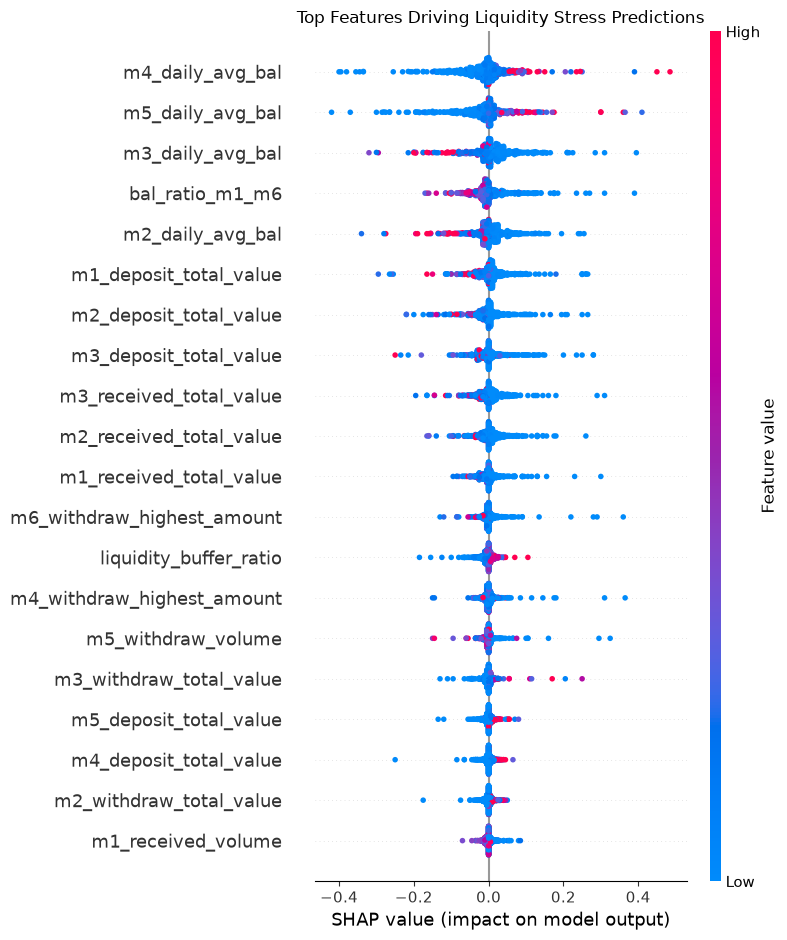

In [4]:
# Install shap if you haven't already:
# !pip install shap

import shap
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Initializing SHAP Explainer...")

# We will sample 500 instances from our validation/test set to keep computation fast
X_sample = X_test.sample(n=500, random_state=42)

# For Scikit-Learn's HistGradientBoosting, the generic Permutation Explainer is highly stable
# We pass the model's predict function and the background dataset
explainer = shap.Explainer(hgb_model.predict, X_sample)

print("Calculating SHAP values (this may take a moment)...")
shap_values = explainer(X_sample)

print("\n==========================================")
print("--- SHAP SUMMARY PLOT ---")
print("==========================================")

# Generate the Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("Top Features Driving Liquidity Stress Predictions")
plt.tight_layout()
plt.show()

In [5]:
import joblib

print("Initiating model serialization...")

# Bundle the model, threshold, and exact feature order
deployment_package = {
    'model': hgb_model,
    'threshold': 0.25,
    'features': list(X.columns)
}

# Export to a binary file
joblib.dump(deployment_package, 'liquidity_risk_engine.pkl')
print("Model successfully saved as 'liquidity_risk_engine.pkl'")

Initiating model serialization...
Model successfully saved as 'liquidity_risk_engine.pkl'
